<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Automated_Mathematical_Derivation_Engine_Adjacency_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Automated Mathematical Derivation Engine with Adjacency Operators and Graphviz

## Motivation

Automated derivation requires a method for choosing among competing symbolic transformations without losing the assumptions that justify each step. A compact expression may conceal restrictions on its domain, and a short derivation may depend on a transformation whose conditions require additional checks. Representing the search as a directed graph preserves these relationships, connecting each candidate expression to its transformation history and the checks supporting its acceptance.

Within this architecture, adjustable costs guide exploration toward a chosen mathematical objective. Acceptance follows a separate policy for checking equivalence, ensuring that a favorable score alone provides no authority to approve a transformation.

## Notation

A derivation carries information about both an expression and the route used to obtain it. Separating these quantities prevents identical expressions reached along different paths from receiving an incorrectly shared history or score.

| Symbol or identifier          | Definition                                                                                      |
| ----------------------------- | ----------------------------------------------------------------------------------------------- |
| $E$                           | Symbolic expression at the current search state.                                                |
| $E'$                          | Candidate expression produced by a transformation.                                              |
| $E_\star$                     | Target expression for an objective requiring an exact structural match.                         |
| $s$                           | Search state containing the expression, assumptions, and information about its derivation path. |
| $\Gamma$                      | Assumptions and domain restrictions associated with a state.                                    |
| $\models$                     | Logical entailment under the stated assumptions.                                                |
| $r$                           | Transformation rule applied to an expression.                                                   |
| $P$                           | Ordered sequence of transformations along a derivation path.                                    |
| $d$                           | Number of transformations along the selected path.                                              |
| $k$                           | Position of a transformation within that path.                                                  |
| $r_k$                         | Rule applied at position $k$.                                                                   |
| $c(r_k)$                      | Cost assigned to rule $r_k$ in the transformation registry.                                     |
| $T(r_{k-1},r_k)$              | Cost assigned to two consecutive rules in the transition table.                                 |
| $C(s)$                        | Weighted score used to rank a search state; smaller values receive higher priority.             |
| $C_{\mathrm{depth}}$          | Depth of the selected derivation path.                                                          |
| $C_{\mathrm{operations}}$     | Operation count of the current expression.                                                      |
| $C_{\mathrm{target}}$         | Structural distance from the target expression.                                                 |
| $C_{\mathrm{canonical}}$      | Penalty measuring departure from the form preferred by the objective.                           |
| $C_{\mathrm{rule}}$           | Accumulated cost of applied transformation rules.                                               |
| $C_{\mathrm{adjacency}}$      | Accumulated cost of consecutive rule transitions.                                               |
| $C_{\mathrm{verification}}$   | Penalty assigned to the strongest applicable verification route recorded for the incoming edge. |
| $w_d,w_o,w_t,w_c,w_r,w_a,w_v$ | Adjustable, nonnegative weights associated with the seven score components.                     |
| $A$                           | Binary adjacency matrix of the recorded derivation graph.                                       |
| $A_{ij}$                      | Entry indicating whether a directed edge connects state $i$ to state $j$.                       |
| $i,j$                         | Indices of recorded search states.                                                              |
| `sympy.count_ops(E)`          | SymPy function returning an operation count for an expression.                                  |

The integers zero and one serve as counting values or chosen scoring baselines. Their appearance introduces no physical constants.

## Fundamental Theory

Symbolic rewriting changes the representation of a mathematical object under specified assumptions. Preserving equivalence requires attention to those assumptions, especially for operations involving division, radicals, or complex functions.

For a rule $r$ applied to an expression $E$, the candidate expression is

$$
E'=r(E).
$$

Acceptance requires the rule’s conditions and an appropriate equivalence check. Within the declared domain, the mathematical requirement is

$$
\Gamma \models E=E'.
$$

Here, $\Gamma$ includes restrictions needed for both expressions to be defined. SymPy supplies symbolic transformations, although its general `simplify` function uses heuristics; a targeted transformation offers a more predictable choice for a specified algebraic objective. [1]

Because the search must preserve how a candidate was obtained, each directed edge records the applied rule and its associated checks. With state indices $i$ and $j$, a binary representation of the recorded graph is

$$
A_{ij}=
\begin{cases}
1, & \text{if a recorded transformation connects state }i\text{ to state }j,\\
0, & \text{otherwise}.
\end{cases}
$$

An edge in this matrix indicates a recorded relationship. Its acceptance status belongs to the accompanying metadata, allowing exploratory candidates and accepted transformations to retain distinct labels.

## Implementation and Control Knobs

Equivalent expressions often compete for attention during a bounded search, and their computational costs differ across objectives. A weighted score makes these preferences inspectable, connecting each ranking decision to an expression property or a recorded feature of its derivation.

Several score components depend on the path, requiring the score to be associated with the search state $s$. The expression alone supplies insufficient information for reconstructing accumulated rule costs or the incoming verification route.

$$
C(s)=
w_d C_{\mathrm{depth}}
+w_o C_{\mathrm{operations}}
+w_t C_{\mathrm{target}}
+w_c C_{\mathrm{canonical}}
+w_r C_{\mathrm{rule}}
+w_a C_{\mathrm{adjacency}}
+w_v C_{\mathrm{verification}}.
$$

All components are evaluated for the current state. Under a penalty convention, the weights and component values are nonnegative, and smaller scores receive higher priority.

| Component      | Inspectable quantity                                                               | Effect of increasing its weight                                    |
| -------------- | ---------------------------------------------------------------------------------- | ------------------------------------------------------------------ |
| Depth          | Number of transformations along the selected path.                                 | Favors shorter derivations.                                        |
| Operations     | `sympy.count_ops(E)`, using SymPy’s counting convention. [2]                       | Favors expressions with fewer counted operations.                  |
| Target         | Declared structural distance from $E_\star$.                                       | Favors expressions closer to the requested representation.         |
| Canonical form | Objective-specific penalty for departure from a preferred form.                    | Strengthens preference for that form.                              |
| Rule cost      | Sum of costs assigned to applied rules.                                            | Discourages paths containing expensive transformations.            |
| Rule adjacency | Sum of costs assigned to consecutive rules.                                        | Strengthens preferences among transformation sequences.            |
| Verification   | Declared penalty for the strongest applicable check recorded on the incoming edge. | Favors the verification routes preferred by the configured policy. |

For a path containing $d$ transformations, its depth and accumulated rule costs are

$$
C_{\mathrm{depth}}=d,
$$

$$
C_{\mathrm{rule}}=
\sum_{k=1}^{d}c(r_k),
$$

$$
C_{\mathrm{adjacency}}=
\sum_{k=2}^{d}T(r_{k-1},r_k).
$$

Empty sums equal zero, giving the initial state zero accumulated rule cost and paths shorter than two transformations zero adjacency cost. The initial state also requires a documented verification penalty, as it has no incoming edge.

Within the transition table, one is a chosen baseline. Values below one favor a transition relative to that baseline, and values above one discourage it. Under additive accumulation, a baseline value of one still increases the score with path length; its neutrality applies to comparisons between individual transitions.

Differences in component magnitude also influence ranking. Reporting each raw component alongside its weighted contribution exposes cases in which operation counts or accumulated costs dominate the configured preferences.

| Computational layer       | Assigned responsibility                                                                        |
| ------------------------- | ---------------------------------------------------------------------------------------------- |
| SymPy                     | Represents exact symbolic expressions and applies supported algebraic transformations.         |
| NetworkX                  | Maintains graph structure and associated attributes, as well as graph algorithms. [3]          |
| Graphviz                  | Supplies layout and rendering for diagrams of the derivation graph.                            |
| Z3                        | Checks supported logical encodings of transformation conditions and equivalence questions. [4] |
| mpmath                    | Evaluates numerical diagnostics at configurable precision.                                     |
| SciPy sparse matrices     | Stores and processes numerical adjacency operators on the CPU.                                 |
| CuPy and CuPy sparse      | Processes compatible numerical arrays and sparse operators on an available CUDA device. [5]    |
| Matplotlib                | Displays matrix diagnostics, including sparsity patterns.                                      |
| Optional SageMath backend | Provides a future extension point, subject to implementing and checking the interface.         |

In this design, NetworkX manages the graph and Graphviz renders its layout. GPU acceleration applies to compatible numerical work; symbolic rewriting requires a separate implementation to execute on the GPU.

## Mathematical and Computational Nuances

A derivation may satisfy an algebraic objective yet require additional restrictions on its domain. Complex functions introduce further sensitivity to branch conventions, making assumptions part of the mathematical state.

Within a supported logical encoding, Z3 checks whether a counterexample to a proposed equivalence exists. An unsatisfiable counterexample query supports equivalence under that encoding; a timeout or an unknown result leaves the question unresolved. The solver’s coverage is determined by its supported theories and the correctness of the translation. [4]

Numerical agreement supplies a different diagnostic. Evaluation with mpmath tests selected inputs at a chosen precision, leaving unsampled points and unexamined domain restrictions outside the check.

Path-dependent scoring also affects duplicate handling. Two states containing the same expression may have different previous rules, changing the cost of their next transition. Merging those states requires a policy that preserves the information used by future scoring decisions.

For bounded searches, a low score expresses preference without guaranteeing a globally optimal derivation. Likewise, a preferred expression form qualifies as canonical only within a specified domain and a procedure that supplies the required uniqueness properties.

## Practical Application and Observation

Search behavior is observable in the accepted derivation, the explored graph, and the computational resources consumed. Comparing these measurements under fixed assumptions and rule definitions reveals how changes to the control knobs affect exploration.

| Observable                   | Interpretation                                                                    |
| ---------------------------- | --------------------------------------------------------------------------------- |
| Accepted path length         | Number of transformations used to reach the objective.                            |
| Final operation count        | Complexity under the selected counting convention.                                |
| Expanded states              | Search effort spent generating successors.                                        |
| Weighted score contributions | Components responsible for ranking decisions.                                     |
| Verification outcomes        | Accepted, rejected, and unresolved transformations under the configured policy.   |
| Elapsed time                 | Combined cost of rewriting, checking, graph processing, and rendering.            |
| Peak memory                  | Resource demand from stored expressions, graph metadata, and numerical operators. |

In the Graphviz rendering, labeled edges expose the sequence of transformations and the checks attached to them. A matrix plot complements that view by showing the distribution of recorded connections, supporting inspection of the adjacency operator without relying on diagram geometry.

## Comparison of Approaches

Expression complexity, derivation history, and verification address different questions about an automated result. Keeping their contributions visible permits targeted comparisons without treating a single score as a complete measure of mathematical quality.

| Approach                   | Main contribution                                                     | Limitation requiring attention                                                             |
| -------------------------- | --------------------------------------------------------------------- | ------------------------------------------------------------------------------------------ |
| Operation-count ranking    | Favors compact expressions under a reproducible metric.               | Algebraic compactness alone determines neither domain correctness nor numerical stability. |
| Target-directed ranking    | Guides exploration toward a requested representation.                 | Structural distance may poorly predict the number of transformations required.             |
| Rule and adjacency costs   | Encodes preferences for transformations and their ordering.           | Scores depend on the selected cost table and retained path information.                    |
| Symbolic or logical checks | Supports acceptance under declared assumptions and supported methods. | Coverage varies with the mathematical domain and checking procedure.                       |
| Numerical checks           | Tests behavior at selected inputs and precision.                      | Finite sampling leaves universal equivalence unresolved.                                   |

The combined design uses adjustable costs to prioritize exploration and a separate checking policy to approve mathematical steps. Its central control principle is that ranking guides the search, and verified conditions govern acceptance.

## Bibliography

Symbolic transformation and automated reasoning provide complementary support for inspecting a derivation. Software documentation defines the behavior of the functions used in that process, including their supported representations and computational limits.

1. SymPy Development Team. (n.d.). *Best Practices*. SymPy 1.14.0 documentation. Accessed September 16, 2026. [Official documentation](https://docs.sympy.org/latest/explanation/best-practices.html).

2. SymPy Development Team. (n.d.). *Core: count_ops*. SymPy 1.14.0 documentation. Accessed September 16, 2026. [API documentation](https://docs.sympy.org/latest/modules/core.html#sympy.core.function.count_ops).

3. NetworkX Developers. (n.d.). *DiGraph: Directed graphs with self loops*. NetworkX documentation. Accessed September 16, 2026. [API documentation](https://networkx.org/documentation/stable/reference/classes/digraph.html).

4. de Moura, L., and Bjørner, N. (2008). Z3: An efficient SMT solver. In *Tools and Algorithms for the Construction and Analysis of Systems*, Lecture Notes in Computer Science, **4963**, 337–340. Springer. [https://doi.org/10.1007/978-3-540-78800-3_24](https://doi.org/10.1007/978-3-540-78800-3_24).

5. CuPy Developers. (n.d.). *Sparse arrays (cupyx.scipy.sparse)*. CuPy documentation. Accessed September 16, 2026. [API documentation](https://docs.cupy.dev/en/stable/reference/scipy_sparse.html).

In [ ]:
"""Install the mathematical derivation stack for Google Colab."""

!apt-get -qq update && apt-get -qq install -y graphviz
!uv pip install -q sympy networkx graphviz z3-solver mpmath cupy-cuda12x scipy

In [23]:
"""Import dependencies and define user-adjustable controls."""

from collections import Counter, deque
import heapq
import itertools
import math
import random

import matplotlib.pyplot as plt
from graphviz import Digraph
import mpmath
import networkx as nx
import numpy as np
import pandas as pd
import scipy.sparse as sps
import sympy as sp
from IPython.display import Math, SVG, display
import z3

try:
    import cupy as cp
    import cupyx.scipy.sparse as cp_sparse
except ImportError:
    cp = None
    cp_sparse = None


# - Core search controls ------------------------------------------------------
SEARCH_MODE = "astar"  # "breadth_first", "best_first", or "astar"
MAX_DEPTH = 5
MAX_NODES = 220
STOP_AFTER_GOALS = 5
TOP_CANDIDATES = 8

# - Verification controls ----------------------------------------------------
MPMATH_SAMPLES = 12
GPU_SAMPLES = 32768
MPMATH_DPS = 70
NUMERIC_TOLERANCE = 1e-10
RANDOM_SEED = 7

# - Search score weights -----------------------------------------------------
SCORE_WEIGHTS = {
    "depth": 1.00,
    "operations": 0.08,
    "target": 1.25,
    "canonical": 1.00,
    "rule": 0.30,
    "adjacency": 0.35,
    "verification": 1.00,
}

# - Rule-transition adjacency costs -----------------------------------------
DEFAULT_RULE_TRANSITION_COST = 1.00
RULE_TRANSITION_COSTS = {
    ("expand", "collect"): 0.35,
    ("expand_trig", "trigsimp"): 0.20,
    ("together", "cancel"): 0.25,
    ("together", "ratsimp"): 0.35,
    ("ratsimp", "factor"): 0.50,
    ("factor", "simplify"): 0.60,
    ("factor", "expand"): 1.75,
    ("cancel", "together"): 1.40,
}

# - Mathematical assumptions ------------------------------------------------
ASSUMPTIONS = {
    "x": {"real": True, "positive": True},
    "y": {"real": True},
    "n": {"integer": True, "nonnegative": True},
}

# - Transformation controls -------------------------------------------------
PERMITTED_RULES = (
    "expand",
    "factor",
    "cancel",
    "together",
    "apart",
    "trigsimp",
    "powsimp",
    "ratsimp",
    "collect",
    "simplify",
)
COLLECT_SYMBOL_NAME = "x"

# - Adjacency controls -------------------------------------------------------
BUILD_RULE_SPECIFIC_ADJACENCY = True
GPU_SPARSE_FRONTIER_STEPS = 4
CLIFFORD_OPERATOR_DIMENSION = 4

# - Graphviz network visualization -------------------------------------------
GRAPHVIZ_ENGINE = "dot"
GRAPHVIZ_FORMAT = "svg"
GRAPHVIZ_RANKDIR = "LR"
GRAPHVIZ_MAX_NODES = 90
GRAPHVIZ_LABEL_MAX_CHARS = 64

# - Matrix plotting -----------------------------------------------------------
PLOT_DPI = 250
FIGSIZE = (13, 8)
plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["savefig.dpi"] = PLOT_DPI

random.seed(RANDOM_SEED)
mpmath.mp.dps = MPMATH_DPS
sp.init_printing()

GPU_AVAILABLE = False
if cp is not None:
    try:
        GPU_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
    except cp.cuda.runtime.CUDARuntimeError:
        GPU_AVAILABLE = False

print(f"CUDA-backed CuPy available: {GPU_AVAILABLE}")

CUDA-backed CuPy available: True


In [24]:
"""Build the mathematical state and the extensible transformation registry."""


def build_symbols(assumptions):
    """Construct SymPy symbols directly from an assumptions dictionary.

    Args:
        assumptions: Mapping from symbol names to SymPy assumption keywords.

    Returns:
        Mapping from names to assumption-aware SymPy symbols.
    """
    return {
        name: sp.Symbol(name, **properties)
        for name, properties in assumptions.items()
    }


SYMBOLS = build_symbols(ASSUMPTIONS)
x = SYMBOLS["x"]
y = SYMBOLS["y"]
n = SYMBOLS["n"]

RULE_REGISTRY = {
    "expand": {
        "transform": lambda expr, ctx: sp.expand(expr),
        "cost": 1.0,
        "category": "algebra",
        "guard": lambda expr, ctx: True,
    },
    "factor": {
        "transform": lambda expr, ctx: sp.factor(expr),
        "cost": 1.0,
        "category": "algebra",
        "guard": lambda expr, ctx: True,
    },
    "cancel": {
        "transform": lambda expr, ctx: sp.cancel(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "together": {
        "transform": lambda expr, ctx: sp.together(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "apart": {
        "transform": lambda expr, ctx: sp.apart(expr),
        "cost": 1.2,
        "category": "rational",
        "guard": lambda expr, ctx: bool(expr.free_symbols),
    },
    "trigsimp": {
        "transform": lambda expr, ctx: sp.trigsimp(expr),
        "cost": 1.0,
        "category": "trigonometric",
        "guard": lambda expr, ctx: expr.has(sp.sin, sp.cos, sp.tan),
    },
    "powsimp": {
        "transform": lambda expr, ctx: sp.powsimp(expr, force=False),
        "cost": 1.0,
        "category": "powers",
        "guard": lambda expr, ctx: True,
    },
    "ratsimp": {
        "transform": lambda expr, ctx: sp.ratsimp(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "collect": {
        "transform": lambda expr, ctx: sp.collect(
            expr,
            ctx.get("collect_symbol", x),
        ),
        "cost": 1.1,
        "category": "polynomial",
        "guard": lambda expr, ctx: ctx.get("collect_symbol") is not None,
    },
    "simplify": {
        "transform": lambda expr, ctx: sp.simplify(expr),
        "cost": 1.5,
        "category": "general",
        "guard": lambda expr, ctx: True,
    },
}

# Example custom registration pattern. Users can add entries without editing
# the search implementation.
RULE_REGISTRY["expand_trig"] = {
    "transform": lambda expr, ctx: sp.expand_trig(expr),
    "cost": 1.3,
    "category": "trigonometric",
    "guard": lambda expr, ctx: expr.has(sp.sin, sp.cos, sp.tan),
}

## Verification, objective-aware scoring, and adjacency-aware search

The verifier first tries exact symbolic equality. If that route does not close the statement and the residual is polynomial, Z3 searches for a counterexample under encoded assumptions. mpmath and CuPy provide independent consistency checks when an exact route is unavailable.

Search objective are represented by a small dictionary. Supported objective kinds are:

- `"simplify"`
- `"factor"`
- `"expand"`
- `"reduce_degree"`
- `"collect"`
- `"prove_equivalence"`
- `"minimize_ops"`
- `"predicate"`
- `"clifford_canonical"` for the domain-specific Clifford reducer later in the notebook.

For scored search, the previous rewrite rule and the candidate rewrite rule define one transition in the rule-adjacency graph. The associated user-visible transition cost contributes to ranking without changing edge verification.


In [25]:
"""Define verification, scoring, and adjacency-aware graph search."""


def verify_equivalence(lhs, rhs, symbols, gpu_samples=GPU_SAMPLES):
    """Verify a transformation using exact, SMT, and numerical routes.

    Args:
        lhs: Source SymPy expression.
        rhs: Candidate SymPy expression.
        symbols: Sequence of participating SymPy symbols.
        gpu_samples: Number of CuPy samples for the GPU consistency check.

    Returns:
        Dictionary describing verification strength and diagnostics.
    """
    residual = sp.simplify(lhs - rhs)
    if residual == 0:
        return {
            "status": "exact_symbolic",
            "proved": True,
            "mpmath_ok": True,
            "cupy_ok": True if GPU_AVAILABLE else None,
            "max_error": 0.0,
        }

    try:
        polynomial = sp.Poly(residual, *symbols)
        z3_vars = {}
        for symbol in symbols:
            z3_vars[symbol] = (
                z3.Int(str(symbol)) if symbol.is_integer
                else z3.Real(str(symbol))
            )

        z3_expr = z3.RealVal(0)
        for powers, coefficient in polynomial.terms():
            coefficient = sp.Rational(coefficient)
            z3_term = (
                z3.RealVal(coefficient.p) / z3.RealVal(coefficient.q)
            )
            for symbol, power in zip(symbols, powers):
                z3_term *= z3_vars[symbol] ** int(power)
            z3_expr += z3_term

        solver = z3.Solver()
        for symbol in symbols:
            variable = z3_vars[symbol]
            if symbol.is_positive:
                solver.add(variable > 0)
            elif symbol.is_nonnegative:
                solver.add(variable >= 0)
            if symbol.is_negative:
                solver.add(variable < 0)
            elif symbol.is_nonpositive:
                solver.add(variable <= 0)

        solver.add(z3_expr != 0)
        smt_result = solver.check()
        if smt_result == z3.unsat:
            return {
                "status": "smt_verified",
                "proved": True,
                "mpmath_ok": True,
                "cupy_ok": True if GPU_AVAILABLE else None,
                "max_error": 0.0,
            }
        if smt_result == z3.sat:
            return {
                "status": "counterexample_found",
                "proved": False,
                "mpmath_ok": False,
                "cupy_ok": False if GPU_AVAILABLE else None,
                "max_error": math.inf,
            }
    except (sp.PolynomialError, TypeError, ValueError, z3.Z3Exception):
        pass

    scalar_fn = sp.lambdify(tuple(symbols), lhs - rhs, modules="mpmath")
    scalar_errors = []
    attempts = 0
    while len(scalar_errors) < MPMATH_SAMPLES and attempts < 12 * MPMATH_SAMPLES:
        attempts += 1
        values = []
        for symbol in symbols:
            if symbol.is_integer:
                low = 0 if symbol.is_nonnegative else -4
                value = random.randint(
                    max(low, 0) if symbol.is_positive else low,
                    5,
                )
                if symbol.is_positive and value == 0:
                    value = 1
            elif symbol.is_positive:
                value = random.uniform(0.125, 3.0)
            elif symbol.is_nonnegative:
                value = random.uniform(0.0, 3.0)
            elif symbol.is_negative:
                value = random.uniform(-3.0, -0.125)
            else:
                value = random.uniform(-3.0, 3.0)
            values.append(value)

        try:
            error = abs(complex(scalar_fn(*values)))
            if math.isfinite(error):
                scalar_errors.append(float(error))
        except (ArithmeticError, TypeError, ValueError, ZeroDivisionError):
            continue

    scalar_max_error = max(scalar_errors, default=math.inf)
    mpmath_ok = scalar_max_error <= NUMERIC_TOLERANCE

    cupy_ok = None
    gpu_max_error = None
    if GPU_AVAILABLE and symbols:
        cupy_modules = {
            "sin": cp.sin,
            "cos": cp.cos,
            "tan": cp.tan,
            "exp": cp.exp,
            "log": cp.log,
            "sqrt": cp.sqrt,
            "Abs": cp.abs,
        }
        gpu_fn = sp.lambdify(tuple(symbols), lhs - rhs, modules=[cupy_modules])
        gpu_values = []
        for index, symbol in enumerate(symbols):
            rng = cp.random.RandomState(RANDOM_SEED + index)
            if symbol.is_integer:
                low = 1 if symbol.is_positive else (
                    0 if symbol.is_nonnegative else -4
                )
                values = rng.randint(low, 6, size=gpu_samples)
            elif symbol.is_positive:
                values = rng.uniform(0.125, 3.0, size=gpu_samples)
            elif symbol.is_nonnegative:
                values = rng.uniform(0.0, 3.0, size=gpu_samples)
            elif symbol.is_negative:
                values = rng.uniform(-3.0, -0.125, size=gpu_samples)
            else:
                values = rng.uniform(-3.0, 3.0, size=gpu_samples)
            gpu_values.append(values)

        try:
            gpu_residual = cp.asarray(gpu_fn(*gpu_values))
            finite = cp.isfinite(gpu_residual)
            if bool(cp.any(finite)):
                gpu_max_error = float(
                    cp.max(cp.abs(gpu_residual[finite])).get()
                )
                cupy_ok = gpu_max_error <= NUMERIC_TOLERANCE
            else:
                cupy_ok = False
                gpu_max_error = math.inf
        except (TypeError, ValueError, cp.cuda.runtime.CUDARuntimeError):
            cupy_ok = None

    max_error = max(
        scalar_max_error,
        gpu_max_error if gpu_max_error is not None else 0.0,
    )
    numeric_ok = mpmath_ok and (cupy_ok in (True, None))
    return {
        "status": "numerically_consistent" if numeric_ok else "failed",
        "proved": False,
        "mpmath_ok": mpmath_ok,
        "cupy_ok": cupy_ok,
        "max_error": max_error,
    }


def score_expression(
    expr,
    depth,
    target,
    objective,
    rule_cost,
    adjacency_cost,
    verification,
):
    """Compute transparent search costs for one mathematical state.

    Args:
        expr: Candidate SymPy expression.
        depth: Search depth of the candidate.
        target: Optional exact structural target.
        objective: Objective configuration dictionary.
        rule_cost: Cumulative transformation-rule cost.
        adjacency_cost: Cumulative consecutive-rule transition cost.
        verification: Verification dictionary for the incoming edge.

    Returns:
        Dictionary containing each score component and the total cost.
    """
    operations = float(sp.count_ops(expr))

    if target is None:
        target_cost = 0.0
    elif sp.srepr(expr) == sp.srepr(target):
        target_cost = 0.0
    else:
        residual = sp.simplify(expr - target)
        target_cost = 1.0 + float(sp.count_ops(residual))

    kind = objective.get("kind", "exact_target") if objective else "exact_target"
    if kind == "factor":
        canonical_cost = float(sp.srepr(expr) != sp.srepr(sp.factor(expr)))
    elif kind == "expand":
        canonical_cost = float(sp.srepr(expr) != sp.srepr(sp.expand(expr)))
    elif kind == "collect":
        symbol = objective.get("symbol", x)
        canonical_cost = float(
            sp.srepr(expr) != sp.srepr(sp.collect(expr, symbol))
        )
    elif kind in ("simplify", "minimize_ops"):
        canonical_cost = operations
    elif kind == "reduce_degree":
        symbol = objective.get("symbol", x)
        try:
            canonical_cost = float(sp.Poly(sp.cancel(expr), symbol).degree())
        except sp.PolynomialError:
            canonical_cost = operations
    elif kind == "predicate":
        predicate = objective.get("predicate")
        canonical_cost = 0.0 if predicate and predicate(expr) else 1.0
    else:
        canonical_cost = 0.0

    verification_penalties = {
        "given": 0.0,
        "exact_symbolic": 0.0,
        "smt_verified": 0.25,
        "numerically_consistent": 1.0,
        "counterexample_found": 20.0,
        "failed": 20.0,
    }
    verification_cost = verification_penalties.get(
        verification.get("status", "failed"),
        20.0,
    )

    components = {
        "depth": float(depth),
        "operations": operations,
        "target": target_cost,
        "canonical": canonical_cost,
        "rule": float(rule_cost),
        "adjacency": float(adjacency_cost),
        "verification": verification_cost,
    }
    total = sum(
        SCORE_WEIGHTS[name] * value
        for name, value in components.items()
    )
    return {**components, "total": float(total)}


def search_derivation(
    start_expr,
    target=None,
    objective=None,
    symbols=(),
    rule_registry=None,
    permitted_rules=(),
    search_mode=SEARCH_MODE,
    context=None,
):
    """Search a verified directed graph of mathematical transformations.

    Args:
        start_expr: Starting SymPy expression.
        target: Optional exact structural target expression.
        objective: Optional objective dictionary.
        symbols: Symbols used by verification.
        rule_registry: Mapping of rule names to transformation metadata.
        permitted_rules: Ordered names of rules allowed in the search.
        search_mode: breadth_first, best_first, or astar.
        context: Extra rule context such as the collection symbol.

    Returns:
        Dictionary containing the graph, selected path, goals, and rankings.
    """
    rule_registry = rule_registry or RULE_REGISTRY
    context = dict(context or {})
    objective = dict(objective or {"kind": "exact_target"})

    def objective_satisfied(expr):
        if target is not None and sp.srepr(expr) == sp.srepr(target):
            return True

        kind = objective.get("kind", "exact_target")
        if kind == "factor":
            return sp.srepr(expr) == sp.srepr(sp.factor(expr))
        if kind == "expand":
            return sp.srepr(expr) == sp.srepr(sp.expand(expr))
        if kind == "simplify":
            return sp.srepr(expr) == sp.srepr(sp.simplify(expr))
        if kind == "collect":
            symbol = objective.get("symbol", x)
            return sp.srepr(expr) == sp.srepr(sp.collect(expr, symbol))
        if kind == "reduce_degree":
            symbol = objective.get("symbol", x)
            maximum = objective.get("max_degree")
            if maximum is None:
                return False
            try:
                return sp.Poly(sp.cancel(expr), symbol).degree() <= maximum
            except sp.PolynomialError:
                return False
        if kind == "prove_equivalence" and target is not None:
            check = verify_equivalence(expr, target, symbols)
            return bool(check["proved"])
        if kind == "predicate":
            predicate = objective.get("predicate")
            return bool(predicate and predicate(expr))
        return False

    start_key = sp.srepr(start_expr)
    start_verification = {
        "status": "given",
        "proved": True,
        "mpmath_ok": True,
        "cupy_ok": True if GPU_AVAILABLE else None,
        "max_error": 0.0,
    }
    start_score = score_expression(
        start_expr,
        0,
        target,
        objective,
        0.0,
        0.0,
        start_verification,
    )

    graph = nx.DiGraph()
    graph.add_node(
        start_key,
        expr=start_expr,
        depth=0,
        verification=start_verification["status"],
        **{f"score_{key}": value for key, value in start_score.items()},
    )

    parent = {start_key: None}
    parent_rule = {start_key: None}
    expressions = {start_key: start_expr}
    goals = []
    insertion_order = itertools.count()

    if search_mode == "breadth_first":
        frontier = deque([(start_key, 0)])
    else:
        frontier = []
        heapq.heappush(
            frontier,
            (start_score["total"], next(insertion_order), start_key, 0),
        )

    while frontier and graph.number_of_nodes() < MAX_NODES:
        if search_mode == "breadth_first":
            current_key, depth = frontier.popleft()
        else:
            _, _, current_key, depth = heapq.heappop(frontier)

        current_expr = expressions[current_key]
        if objective_satisfied(current_expr):
            if current_key not in goals:
                goals.append(current_key)
            if len(goals) >= STOP_AFTER_GOALS:
                break
            continue

        if depth >= MAX_DEPTH:
            continue

        for rule_name in permitted_rules:
            if rule_name not in rule_registry:
                raise KeyError(f"Unknown transformation rule: {rule_name}")

            rule = rule_registry[rule_name]
            if not rule["guard"](current_expr, context):
                continue

            try:
                candidate = sp.sympify(rule["transform"](current_expr, context))
            except (
                NotImplementedError,
                TypeError,
                ValueError,
                ZeroDivisionError,
                sp.SympifyError,
            ):
                continue

            candidate_key = sp.srepr(candidate)
            if candidate_key == current_key:
                continue

            verification = verify_equivalence(
                current_expr,
                candidate,
                symbols,
            )
            if verification["status"] in ("failed", "counterexample_found"):
                continue

            candidate_depth = depth + 1
            previous_rule = parent_rule[current_key]
            transition_cost = 0.0
            if previous_rule is not None:
                transition_cost = RULE_TRANSITION_COSTS.get(
                    (previous_rule, rule_name),
                    DEFAULT_RULE_TRANSITION_COST,
                )

            cumulative_rule_cost = (
                graph.nodes[current_key]["score_rule"] + rule["cost"]
            )
            cumulative_adjacency_cost = (
                graph.nodes[current_key]["score_adjacency"] + transition_cost
            )
            score = score_expression(
                candidate,
                candidate_depth,
                target,
                objective,
                cumulative_rule_cost,
                cumulative_adjacency_cost,
                verification,
            )

            if candidate_key not in graph:
                graph.add_node(
                    candidate_key,
                    expr=candidate,
                    depth=candidate_depth,
                    verification=verification["status"],
                    **{f"score_{key}": value for key, value in score.items()},
                )
                parent[candidate_key] = current_key
                parent_rule[candidate_key] = rule_name
                expressions[candidate_key] = candidate

                if search_mode == "breadth_first":
                    frontier.append((candidate_key, candidate_depth))
                else:
                    if search_mode == "best_first":
                        priority = (
                            SCORE_WEIGHTS["operations"] * score["operations"]
                            + SCORE_WEIGHTS["target"] * score["target"]
                            + SCORE_WEIGHTS["canonical"] * score["canonical"]
                            + SCORE_WEIGHTS["adjacency"] * score["adjacency"]
                            + SCORE_WEIGHTS["verification"]
                            * score["verification"]
                        )
                    elif search_mode == "astar":
                        priority = score["total"]
                    else:
                        raise ValueError(
                            "SEARCH_MODE must be breadth_first, best_first, or astar."
                        )
                    heapq.heappush(
                        frontier,
                        (
                            priority,
                            next(insertion_order),
                            candidate_key,
                            candidate_depth,
                        ),
                    )

            stored_depth = graph.nodes[candidate_key]["depth"]
            if stored_depth == candidate_depth:
                graph.add_edge(
                    current_key,
                    candidate_key,
                    rule=rule_name,
                    category=rule["category"],
                    rule_cost=float(rule["cost"]),
                    transition_cost=float(transition_cost),
                    verification=verification["status"],
                )

    candidate_keys = goals or [
        key for key in graph.nodes
        if key != start_key and graph.out_degree(key) == 0
    ]
    if not candidate_keys:
        candidate_keys = [key for key in graph.nodes if key != start_key]

    ranked = sorted(
        candidate_keys,
        key=lambda key: graph.nodes[key]["score_total"],
    )
    selected_key = ranked[0] if ranked else start_key

    selected_path = []
    cursor = selected_key
    while cursor is not None:
        selected_path.append(
            {
                "key": cursor,
                "expr": expressions[cursor],
                "rule": parent_rule[cursor],
            }
        )
        cursor = parent[cursor]
    selected_path.reverse()

    return {
        "graph": graph,
        "start_key": start_key,
        "selected_key": selected_key,
        "selected_path": selected_path,
        "goal_keys": goals,
        "ranked_keys": ranked,
    }

## Demonstration 1: symbolic polynomial derivation

This example asks for an exact structural target. The search may explore several equality-preserving transformations, but only independently verified edges enter the graph.

In [26]:
"""Derive a factored polynomial target and inspect ranked candidates."""

POLY_START = sp.expand((x + 1) ** 4)
POLY_TARGET = (x + 1) ** 4

poly_result = search_derivation(
    start_expr=POLY_START,
    target=POLY_TARGET,
    objective={"kind": "exact_target"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES,
    search_mode=SEARCH_MODE,
    context={"collect_symbol": x},
)

assert sp.srepr(poly_result["selected_path"][-1]["expr"]) == sp.srepr(POLY_TARGET)

for index, step in enumerate(poly_result["selected_path"]):
    if index == 0:
        display(Math(rf"E_0={sp.latex(step['expr'])}"))
    else:
        display(
            Math(
                rf"E_{{{index - 1}}}"
                rf"\xrightarrow{{\mathrm{{{step['rule']}}}}}"
                rf"E_{{{index}}}={sp.latex(step['expr'])}"
            )
        )

candidate_rows = []
for key in poly_result["ranked_keys"][:TOP_CANDIDATES]:
    node = poly_result["graph"].nodes[key]
    candidate_rows.append(
        {
            "path_length": node["depth"],
            "symbolic_complexity": node["score_operations"],
            "adjacency_cost": node["score_adjacency"],
            "final_score": node["score_total"],
            "verification_state": node["verification"],
            "terminal_expression": sp.sstr(node["expr"]),
        }
    )

candidate_table = pd.DataFrame(candidate_rows)
display(candidate_table)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,path_length,symbolic_complexity,adjacency_cost,final_score,verification_state,terminal_expression
0,1,2.0,0.0,1.46,exact_symbolic,(x + 1)**4


## Derivation graph visualization

NetworkX retains the derivation DAG, path selection, node metadata, and edge metadata. Graphviz receives that graph for hierarchical layout and SVG rendering. The selected derivation is emphasized structurally, while competing branches remain visible.


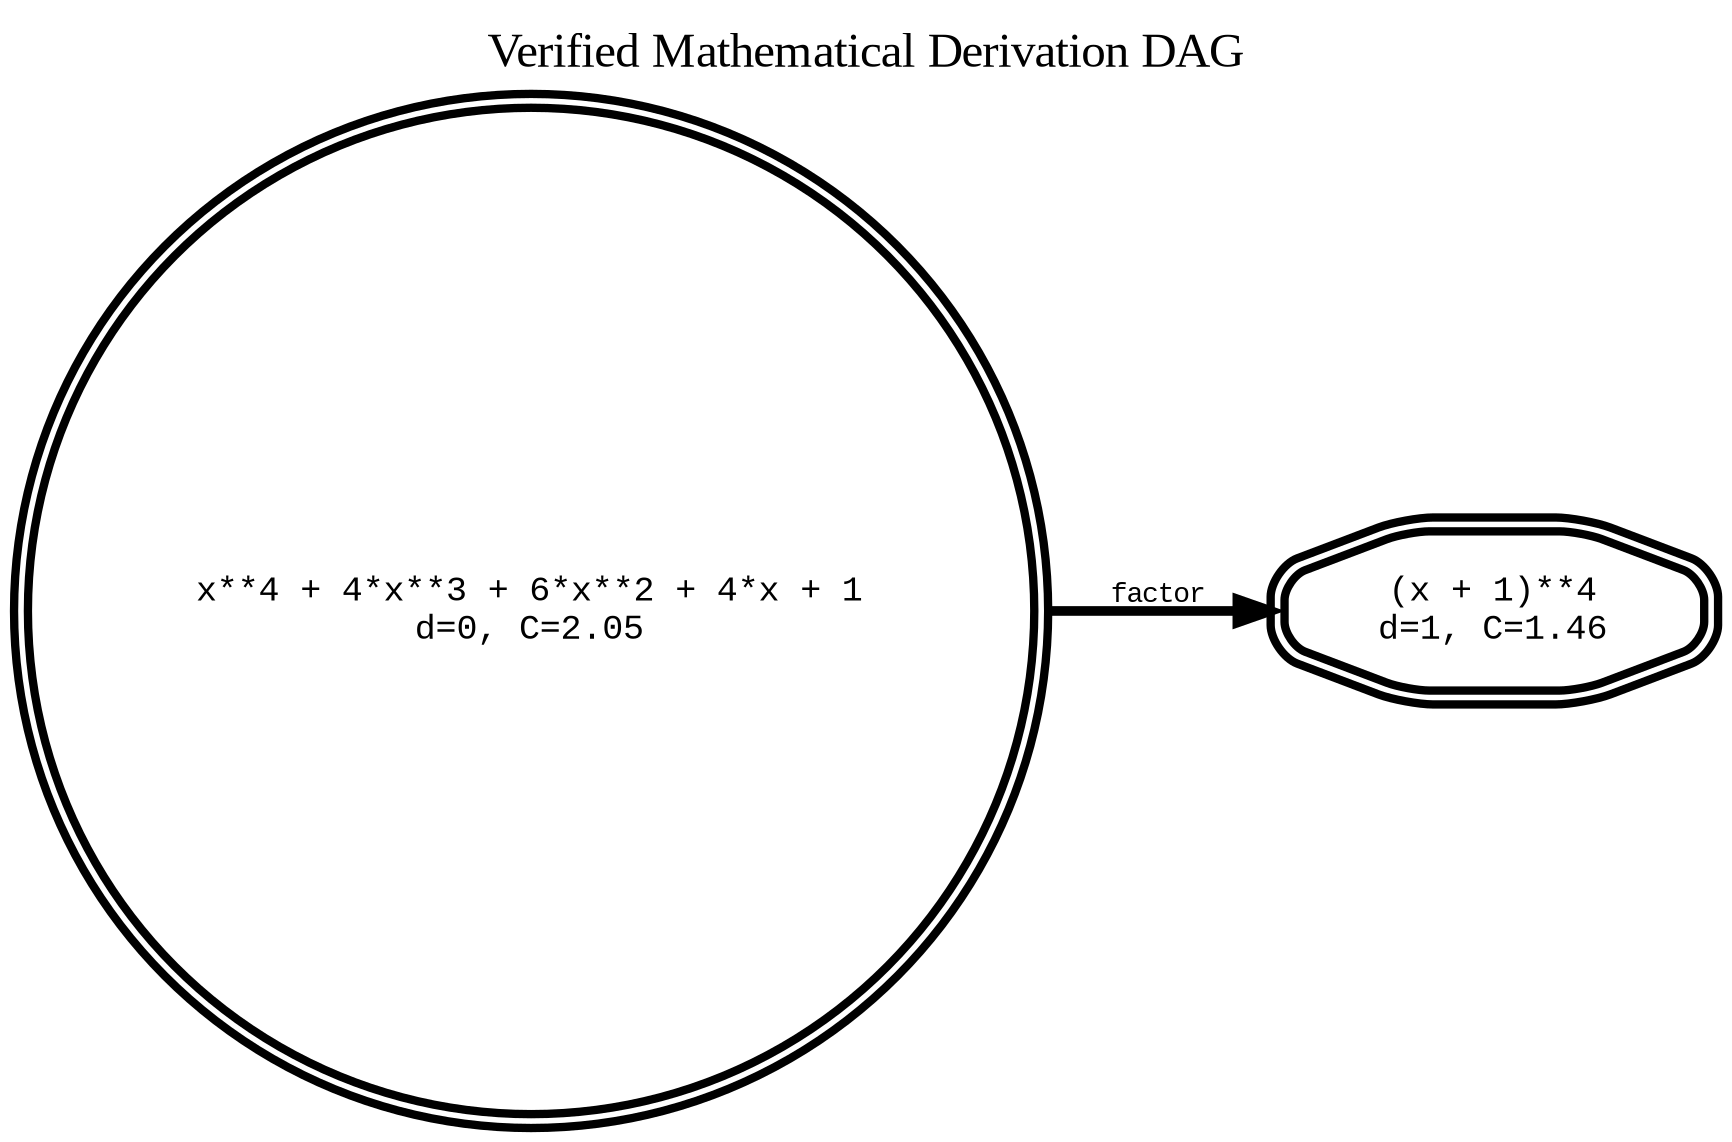

Saved 250 DPI PNG: /content/rule_transition_adjacency_costs.png


In [27]:
"""Render NetworkX mathematical graphs with Graphviz as a downloadable 250 DPI PNG."""

from io import BytesIO
from pathlib import Path

from google.colab import files
from graphviz import Digraph
from IPython.display import Image, display

# ============================================================
# Control knobs
# ============================================================
GRAPHVIZ_DPI = 250
GRAPHVIZ_FORMAT = "png"
GRAPH_PNG_FILENAME = "verified_mathematical_derivation_dag.png"


def render_networkx_graph(
    graph,
    *,
    title,
    selected_nodes=(),
    selected_edges=(),
    node_labels=None,
    edge_labels=None,
    rankdir=GRAPHVIZ_RANKDIR,
    max_nodes=GRAPHVIZ_MAX_NODES,
):
    """Render a NetworkX directed graph using Graphviz.

    NetworkX retains graph construction, traversal, scoring, and subgraph
    selection. Graphviz performs hierarchical layout and PNG rendering.

    Args:
        graph: NetworkX directed graph.
        title: Graph title displayed by Graphviz.
        selected_nodes: Ordered nodes on a highlighted path or structure.
        selected_edges: Edges to emphasize.
        node_labels: Optional mapping from graph nodes to display labels.
        edge_labels: Optional mapping from edge tuples to display labels.
        rankdir: Graphviz rank direction.
        max_nodes: Maximum number of nodes shown in the rendered view.

    Returns:
        Tuple containing the Graphviz Digraph and the NetworkX view rendered.
    """
    selected_nodes = tuple(selected_nodes)
    selected_node_set = set(selected_nodes)
    selected_edge_set = set(selected_edges)

    if graph.number_of_nodes() > max_nodes:
        keep_nodes = set(selected_nodes)
        for node in selected_nodes:
            keep_nodes.update(graph.predecessors(node))
            keep_nodes.update(graph.successors(node))

        if len(keep_nodes) < max_nodes:
            remaining = [
                node
                for node in graph.nodes
                if node not in keep_nodes
            ]
            remaining.sort(
                key=lambda node: (
                    graph.nodes[node].get("depth", math.inf),
                    graph.nodes[node].get("score_total", math.inf),
                    str(node),
                )
            )
            keep_nodes.update(
                remaining[: max_nodes - len(keep_nodes)]
            )

        graph_view = graph.subgraph(keep_nodes).copy()
    else:
        graph_view = graph.copy()

    dot = Digraph(
        name="mathematical_graph",
        engine=GRAPHVIZ_ENGINE,
        format=GRAPHVIZ_FORMAT,
    )
    dot.attr(
        label=title,
        labelloc="t",
        rankdir=rankdir,
        splines="spline",
        overlap="false",
        concentrate="false",
        bgcolor="transparent",
        dpi=str(GRAPHVIZ_DPI),
    )
    dot.attr(
        "node",
        fontname="DejaVu Sans",
        fontsize="10",
        margin="0.08,0.05",
    )
    dot.attr(
        "edge",
        fontname="DejaVu Sans",
        fontsize="8",
        arrowsize="0.75",
    )

    node_ids = {
        node: f"n{index}"
        for index, node in enumerate(graph_view.nodes)
    }

    for node, data in graph_view.nodes(data=True):
        if node_labels is not None and node in node_labels:
            label = str(node_labels[node])
        elif "expr" in data:
            label = sp.sstr(data["expr"])
        else:
            label = str(node)

        if len(label) > GRAPHVIZ_LABEL_MAX_CHARS:
            label = f"{label[: GRAPHVIZ_LABEL_MAX_CHARS - 1]}…"

        metadata = []
        if "depth" in data:
            metadata.append(f"d={data['depth']}")
        if "score_total" in data:
            metadata.append(f"C={data['score_total']:.2f}")
        if metadata:
            label = f"{label}\\n" + ", ".join(metadata)

        attributes = {
            "label": label,
            "shape": "ellipse",
            "penwidth": "1.0",
        }
        if node in selected_node_set:
            attributes.update(
                {
                    "shape": "box",
                    "style": "rounded,bold",
                    "penwidth": "2.4",
                }
            )
        if selected_nodes and node == selected_nodes[0]:
            attributes["shape"] = "doublecircle"
        if selected_nodes and node == selected_nodes[-1]:
            attributes["shape"] = "doubleoctagon"

        dot.node(node_ids[node], **attributes)

    for source, target, data in graph_view.edges(data=True):
        edge = (source, target)
        if edge_labels is not None and edge in edge_labels:
            label = str(edge_labels[edge])
        else:
            label = str(data.get("rule", ""))

        attributes = {
            "label": label,
            "penwidth": "1.0",
        }
        if edge in selected_edge_set:
            attributes.update(
                {
                    "style": "bold",
                    "penwidth": "2.8",
                    "arrowsize": "0.95",
                }
            )

        dot.edge(
            node_ids[source],
            node_ids[target],
            **attributes,
        )

    return dot, graph_view


graph = poly_result["graph"]
selected_keys = [
    step["key"]
    for step in poly_result["selected_path"]
]
selected_edges = list(
    zip(selected_keys[:-1], selected_keys[1:])
)

derivation_labels = {
    key: sp.sstr(data["expr"])
    for key, data in graph.nodes(data=True)
}

derivation_dot, derivation_view = render_networkx_graph(
    graph,
    title="Verified Mathematical Derivation DAG",
    selected_nodes=selected_keys,
    selected_edges=selected_edges,
    node_labels=derivation_labels,
)

# ============================================================
# In-memory render, inline display.
# ============================================================
png_bytes = derivation_dot.pipe(format="png")
png_buffer = BytesIO(png_bytes)

display(Image(data=png_buffer.getvalue()))

DERIVATION_DOT_SOURCE = derivation_dot.source

print(f"Saved 250 DPI PNG: {output_path.resolve()}")

## Sparse expression adjacency and rule-resolved operators

The explored NetworkX graph can be written as a sparse matrix without discarding symbolic metadata. The unweighted operator records verified reachability, the weighted operator records explicit edge costs, and each rule-specific operator $A^{(r)}$ isolates one rewrite family.

For a state vector $v_k$ marking the current frontier, sparse multiplication with $A^\mathsf{T}$ advances one graph step:

$$
v_{k+1}=A^\mathsf{T}v_k.
$$

On a CUDA runtime the same operator can be copied to `cupyx.scipy.sparse` for batched frontier propagation. This representation is most useful after the symbolic engine has generated and verified the graph; it does not replace SymPy's symbolic rewrite logic.


In [28]:
"""Build sparse expression and rule-specific adjacency operators."""


def build_adjacency_views(graph):
    """Convert a derivation graph into sparse adjacency representations.

    Args:
        graph: NetworkX directed derivation graph.

    Returns:
        Dictionary containing node order, sparse adjacency matrices, and
        optional CUDA sparse matrices.
    """
    node_order = list(graph.nodes)
    node_index = {key: index for index, key in enumerate(node_order)}
    shape = (len(node_order), len(node_order))

    rows = []
    columns = []
    weights = []
    rules = set()

    for source, target, data in graph.edges(data=True):
        rows.append(node_index[source])
        columns.append(node_index[target])
        weights.append(
            float(data.get("rule_cost", 1.0))
            + float(data.get("transition_cost", 0.0))
        )
        rules.add(data["rule"])

    adjacency = sps.csr_matrix(
        (np.ones(len(rows), dtype=np.float64), (rows, columns)),
        shape=shape,
    )
    weighted = sps.csr_matrix(
        (np.asarray(weights, dtype=np.float64), (rows, columns)),
        shape=shape,
    )

    rule_adjacency = {}
    if BUILD_RULE_SPECIFIC_ADJACENCY:
        for rule_name in sorted(rules):
            rule_rows = []
            rule_columns = []
            for source, target, data in graph.edges(data=True):
                if data["rule"] == rule_name:
                    rule_rows.append(node_index[source])
                    rule_columns.append(node_index[target])
            rule_adjacency[rule_name] = sps.csr_matrix(
                (
                    np.ones(len(rule_rows), dtype=np.float64),
                    (rule_rows, rule_columns),
                ),
                shape=shape,
            )

    gpu_adjacency = None
    gpu_weighted = None
    if GPU_AVAILABLE and cp_sparse is not None:
        gpu_adjacency = cp_sparse.csr_matrix(adjacency)
        gpu_weighted = cp_sparse.csr_matrix(weighted)

    return {
        "node_order": node_order,
        "node_index": node_index,
        "adjacency": adjacency,
        "weighted": weighted,
        "rule_adjacency": rule_adjacency,
        "gpu_adjacency": gpu_adjacency,
        "gpu_weighted": gpu_weighted,
    }


adjacency_views = build_adjacency_views(poly_result["graph"])
A_EXPR = adjacency_views["adjacency"]
W_EXPR = adjacency_views["weighted"]

print("Expression states:", A_EXPR.shape[0])
print("Verified directed edges:", A_EXPR.nnz)
print("Adjacency density:", A_EXPR.nnz / max(1, A_EXPR.shape[0] ** 2))

rule_rows = [
    {
        "rule": rule_name,
        "edges": matrix.nnz,
    }
    for rule_name, matrix in adjacency_views["rule_adjacency"].items()
]
display(pd.DataFrame(rule_rows).sort_values("edges", ascending=False))

selected_keys = [step["key"] for step in poly_result["selected_path"]]
selected_indices = [adjacency_views["node_index"][key] for key in selected_keys]
for source_index, target_index in zip(
    selected_indices[:-1],
    selected_indices[1:],
):
    assert A_EXPR[source_index, target_index] == 1.0

if GPU_AVAILABLE and adjacency_views["gpu_adjacency"] is not None:
    gpu_frontier = cp.zeros(A_EXPR.shape[0], dtype=cp.float32)
    gpu_frontier[selected_indices[0]] = 1.0
    gpu_visited = gpu_frontier.copy()

    for _ in range(GPU_SPARSE_FRONTIER_STEPS):
        gpu_frontier = adjacency_views["gpu_adjacency"].T @ gpu_frontier
        gpu_frontier = (gpu_frontier > 0).astype(cp.float32)
        gpu_visited = cp.maximum(gpu_visited, gpu_frontier)

    print("GPU sparse reachable states:", int(cp.count_nonzero(gpu_visited).get()))
else:
    print("GPU sparse frontier propagation is available on a CUDA runtime.")

Expression states: 2
Verified directed edges: 1
Adjacency density: 0.25


,rule,edges
0,factor,1


GPU sparse reachable states: 2


## Rule-transition adjacency visualization

The transformation-sequence prior is represented as a NetworkX directed graph. Graphviz renders the rule-transition network, with edge labels equal to the configured adjacency costs used during search.


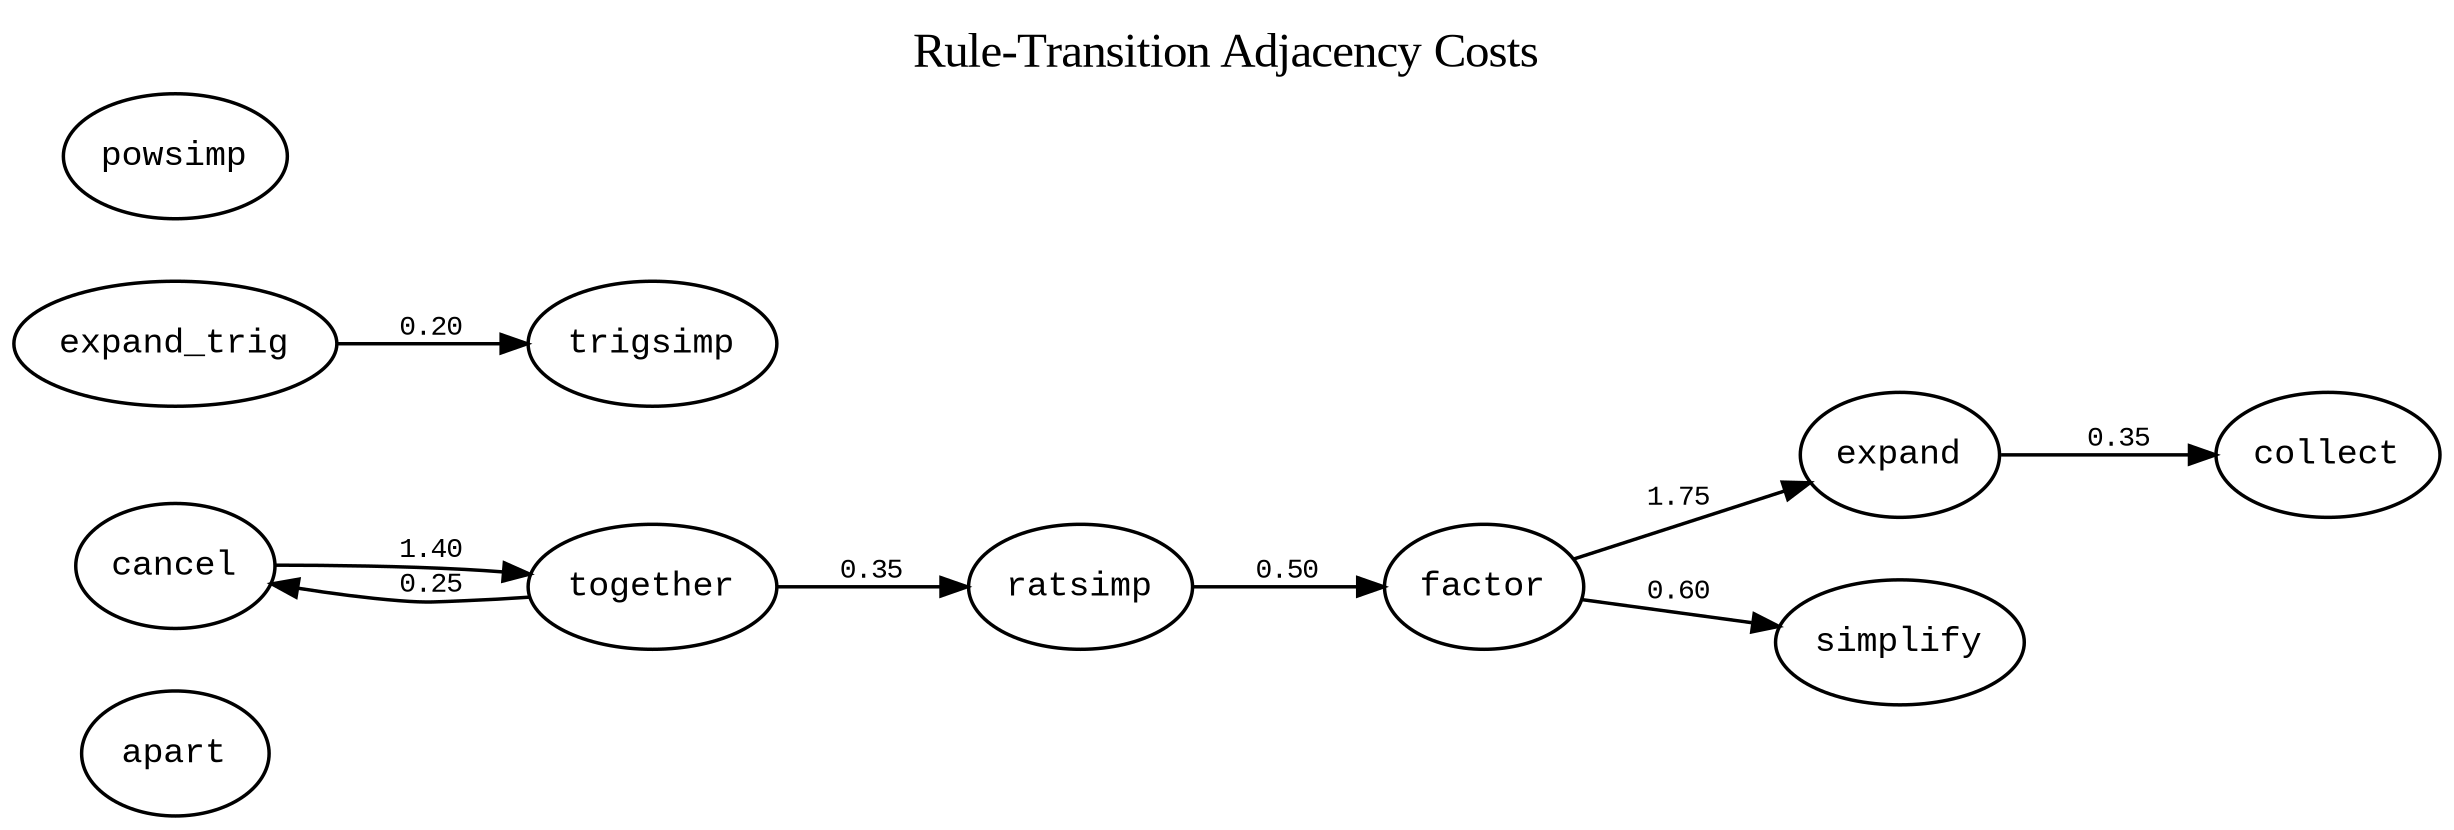

Saved 250 DPI PNG: /content/rule_transition_adjacency_costs.png


In [29]:
"""Render rule-transition adjacency as a downloadable 250 DPI PNG."""

from io import BytesIO
from pathlib import Path

from google.colab import files
from IPython.display import Image, display

# ============================================================
# Control knobs
# ============================================================
RULE_GRAPH_DPI = 250
RULE_GRAPH_PNG_FILENAME = "rule_transition_adjacency_costs.png"

# ============================================================
# Build the rule-transition graph
# ============================================================
rule_transition_graph = nx.DiGraph()

rule_names = set(PERMITTED_RULES)
for source_rule, target_rule in RULE_TRANSITION_COSTS:
    rule_names.add(source_rule)
    rule_names.add(target_rule)

for rule_name in sorted(rule_names):
    rule_transition_graph.add_node(rule_name)

for (
    source_rule,
    target_rule
), transition_cost in RULE_TRANSITION_COSTS.items():
    rule_transition_graph.add_edge(
        source_rule,
        target_rule,
        transition_cost=float(transition_cost),
    )

# ============================================================
# Construct display labels
# ============================================================
rule_edge_labels = {
    (source, target): f"{data['transition_cost']:.2f}"
    for source, target, data
    in rule_transition_graph.edges(data=True)
}

rule_node_labels = {
    node: node
    for node in rule_transition_graph.nodes
}

# ============================================================
# Render with NetworkX + Graphviz
# ============================================================
rule_transition_dot, rule_transition_view = render_networkx_graph(
    rule_transition_graph,
    title="Rule-Transition Adjacency Costs",
    node_labels=rule_node_labels,
    edge_labels=rule_edge_labels,
    rankdir="LR",
)

# Explicitly enforce 250 DPI for this rendered graph.
rule_transition_dot.attr(dpi=str(RULE_GRAPH_DPI))

# ============================================================
# In-memory PNG render
# ============================================================
rule_transition_png = rule_transition_dot.pipe(format="png")
rule_transition_buffer = BytesIO(rule_transition_png)

# Display the exact in-memory PNG.
display(Image(data=rule_transition_buffer.getvalue()))

# Retain the DOT representation for reproducible rendering.
RULE_TRANSITION_DOT_SOURCE = rule_transition_dot.source

print(f"Saved 250 DPI PNG: {output_path.resolve()}")

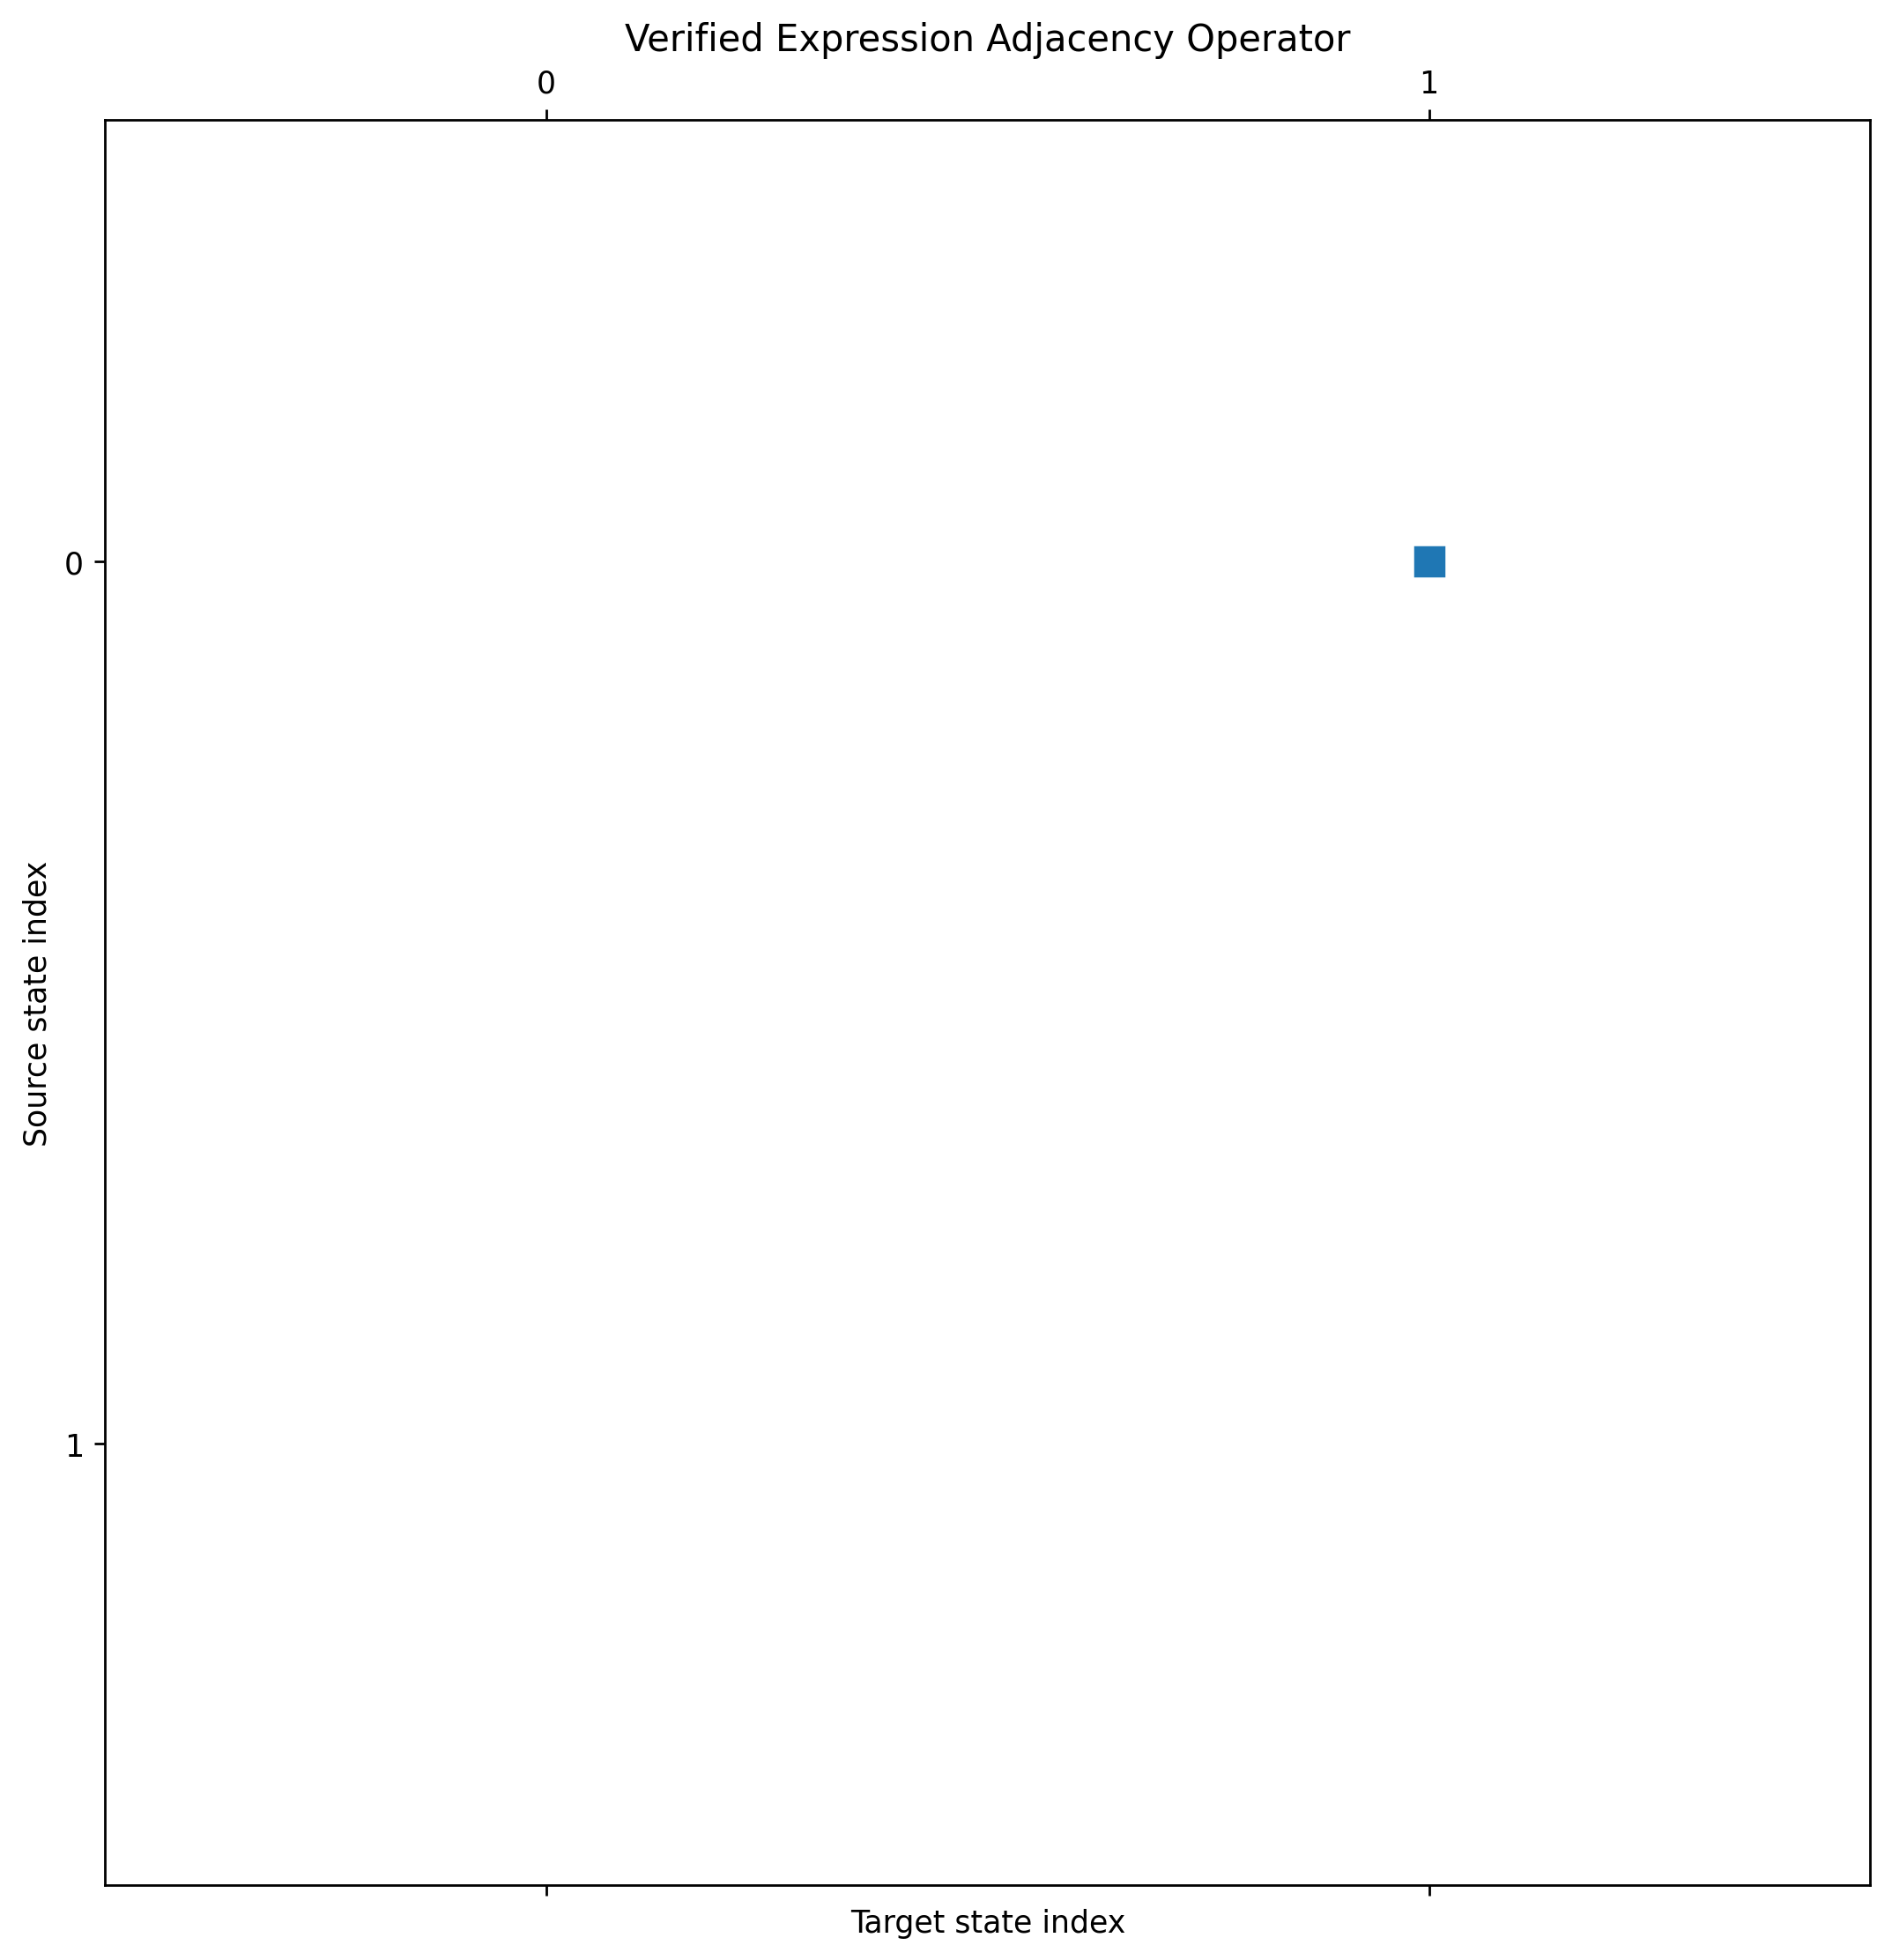

In [30]:
"""Visualize the sparsity pattern of the expression adjacency operator."""

fig, ax = plt.subplots(figsize=(9, 9))
ax.spy(A_EXPR, markersize=9)
ax.set_title("Verified Expression Adjacency Operator")
ax.set_xlabel("Target state index")
ax.set_ylabel("Source state index")
fig.tight_layout()
plt.show()

## Demonstration 2: trigonometric identity derivation

The target is structurally different from the starting expression, so the search records a transformation path instead of stopping merely because the two expressions are mathematically equivalent.

In [31]:
"""Derive a standard trigonometric identity."""

TRIG_START = sp.sin(x) ** 2 + sp.cos(x) ** 2
TRIG_TARGET = sp.Integer(1)

trig_result = search_derivation(
    start_expr=TRIG_START,
    target=TRIG_TARGET,
    objective={"kind": "exact_target"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES + ("expand_trig",),
    search_mode="best_first",
    context={"collect_symbol": x},
)

assert sp.srepr(trig_result["selected_path"][-1]["expr"]) == sp.srepr(TRIG_TARGET)

for index, step in enumerate(trig_result["selected_path"]):
    label = "start" if index == 0 else step["rule"]
    print(f"{index:>2}: {label:<12} {sp.sstr(step['expr'])}")

 0: start        sin(x)**2 + cos(x)**2
 1: trigsimp     1


## Demonstration 3: objective-driven derivation without an exact target

Here the engine receives `{"kind": "factor"}` instead of a target. Completion means the current expression is already in the structural form returned by `SymPy.factor`.

In [32]:
"""Search for a factorized canonical form without specifying a target."""

OBJECTIVE_START = x**4 - 5 * x**2 + 4

objective_result = search_derivation(
    start_expr=OBJECTIVE_START,
    target=None,
    objective={"kind": "factor"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES,
    search_mode="astar",
    context={"collect_symbol": x},
)

objective_terminal = objective_result["selected_path"][-1]["expr"]
assert sp.srepr(objective_terminal) == sp.srepr(sp.factor(objective_terminal))

display(
    Math(
        rf"{sp.latex(OBJECTIVE_START)}"
        rf"\longrightarrow {sp.latex(objective_terminal)}"
    )
)

<IPython.core.display.Math object>

## Clifford algebra, graded algebra, and signed adjacency operators

For an orthogonal basis, the Clifford relations are

$$
e_i e_j + e_j e_i = 2g_{ij},
$$

and in the diagonal case

$$
e_i^2=Q(e_i).
$$

The canonical word reducer sorts basis indices, tracks the parity of transpositions, and collapses repeated basis elements into metric factors. A homogeneous Clifford word has $\mathbb Z/2\mathbb Z$ grade equal to its canonical word length modulo two.

The same algebra admits a sparse adjacency representation. For each generator $e_i$, left multiplication defines a signed sparse operator $M_i$ on the $2^n$ canonical basis blades. Each source blade has exactly one target blade under multiplication by a fixed generator. The operators satisfy

$$
M_i^2=g_{ii}I,
$$

and for $i\ne j$ in an orthogonal basis,

$$
M_iM_j+M_jM_i=0.
$$

For homogeneous graded tensor factors, multiplication uses the Koszul sign

$$
(x_1\otimes x_2)(y_1\otimes y_2)
=
(-1)^{|x_2||y_1|}(x_1y_1)\otimes(x_2y_2).
$$


In [33]:
"""Implement Clifford reduction, grading, and sparse generator operators."""


def reduce_clifford_word(word, diagonal_metric):
    """Reduce an orthogonal Clifford word to canonical ordered form.

    Args:
        word: Iterable of integer basis indices.
        diagonal_metric: Mapping i -> Q(e_i) = g_ii.

    Returns:
        Dictionary with coefficient, canonical word, and Z/2Z grade.
    """
    word = tuple(word)
    inversions = sum(
        left > right
        for index, left in enumerate(word)
        for right in word[index + 1 :]
    )
    coefficient = sp.Integer(-1) ** inversions
    counts = Counter(word)
    canonical = []

    for basis_index in sorted(counts):
        if basis_index not in diagonal_metric:
            raise KeyError(f"Missing Q(e_{basis_index}) in the metric.")
        count = counts[basis_index]
        coefficient *= sp.sympify(diagonal_metric[basis_index]) ** (count // 2)
        if count % 2:
            canonical.append(basis_index)

    return {
        "coefficient": sp.simplify(coefficient),
        "word": tuple(canonical),
        "grade": len(canonical) % 2,
    }


def graded_tensor_product(left, right):
    """Multiply homogeneous tensor factors using the Koszul sign rule.

    Args:
        left: Tuple ((x1, grade_x1), (x2, grade_x2)).
        right: Tuple ((y1, grade_y1), (y2, grade_y2)).

    Returns:
        Dictionary containing the Koszul sign and resulting graded factors.
    """
    (x1, grade_x1), (x2, grade_x2) = left
    (y1, grade_y1), (y2, grade_y2) = right
    sign = (-1) ** (grade_x2 * grade_y1)
    return {
        "sign": sign,
        "left_factor": x1 * y1,
        "right_factor": x2 * y2,
        "grades": (
            (grade_x1 + grade_y1) % 2,
            (grade_x2 + grade_y2) % 2,
        ),
    }


def build_clifford_adjacency_operators(dimension, diagonal_metric):
    """Build signed sparse left-multiplication operators for Clifford generators.

    Args:
        dimension: Number of orthogonal basis generators.
        diagonal_metric: Mapping i -> Q(e_i) = g_ii.

    Returns:
        Dictionary with basis labels and one CSR operator per generator.
    """
    basis_size = 1 << dimension
    basis_labels = []
    for mask in range(basis_size):
        indices = [
            index + 1
            for index in range(dimension)
            if mask & (1 << index)
        ]
        basis_labels.append(tuple(indices))

    operators = {}
    for basis_index in range(1, dimension + 1):
        if basis_index not in diagonal_metric:
            raise KeyError(f"Missing Q(e_{basis_index}) in the metric.")

        bit = 1 << (basis_index - 1)
        lower_bits = bit - 1
        rows = []
        columns = []
        data = []

        for source_mask in range(basis_size):
            swaps = (source_mask & lower_bits).bit_count()
            coefficient = -1.0 if swaps % 2 else 1.0
            if source_mask & bit:
                coefficient *= float(diagonal_metric[basis_index])

            target_mask = source_mask ^ bit
            rows.append(target_mask)
            columns.append(source_mask)
            data.append(coefficient)

        operators[basis_index] = sps.csr_matrix(
            (np.asarray(data), (rows, columns)),
            shape=(basis_size, basis_size),
        )

    return {
        "basis_labels": basis_labels,
        "operators": operators,
    }


NEGATIVE_METRIC = {1: -1, 2: -1, 3: -1, 4: -1}
CLIFFORD_WORD = (3, 1, 2, 1, 3)
clifford_result = reduce_clifford_word(CLIFFORD_WORD, NEGATIVE_METRIC)

print("Input word:", CLIFFORD_WORD)
print("Coefficient:", clifford_result["coefficient"])
print("Canonical word:", clifford_result["word"])
print("Z/2Z grade:", clifford_result["grade"])

CLIFFORD_OBJECTIVE = {"kind": "clifford_canonical"}
assert clifford_result["word"] == tuple(sorted(clifford_result["word"]))

a, b, c, d = sp.symbols("a b c d", commutative=False)
koszul_result = graded_tensor_product(
    ((a, 0), (b, 1)),
    ((c, 1), (d, 0)),
)
print("Koszul sign:", koszul_result["sign"])
assert koszul_result["sign"] == -1

clifford_adjacency = build_clifford_adjacency_operators(
    CLIFFORD_OPERATOR_DIMENSION,
    NEGATIVE_METRIC,
)
clifford_operators = clifford_adjacency["operators"]
clifford_identity = sps.identity(
    1 << CLIFFORD_OPERATOR_DIMENSION,
    format="csr",
)

for basis_index, operator in clifford_operators.items():
    square_residual = operator @ operator - NEGATIVE_METRIC[basis_index] * clifford_identity
    assert square_residual.nnz == 0 or np.max(np.abs(square_residual.data)) < 1e-12

for left_index in range(1, CLIFFORD_OPERATOR_DIMENSION + 1):
    for right_index in range(left_index + 1, CLIFFORD_OPERATOR_DIMENSION + 1):
        anticommutator = (
            clifford_operators[left_index] @ clifford_operators[right_index]
            + clifford_operators[right_index] @ clifford_operators[left_index]
        )
        assert anticommutator.nnz == 0 or np.max(np.abs(anticommutator.data)) < 1e-12

print("Clifford sparse operator dimension:", clifford_identity.shape)
print("Nonzeros per generator:", clifford_operators[1].nnz)

if GPU_AVAILABLE and cp_sparse is not None:
    gpu_clifford = {
        index: cp_sparse.csr_matrix(operator)
        for index, operator in clifford_operators.items()
    }
    gpu_identity = cp_sparse.identity(
        clifford_identity.shape[0],
        dtype=cp.float64,
        format="csr",
    )
    gpu_residual = (
        gpu_clifford[1] @ gpu_clifford[1]
        - NEGATIVE_METRIC[1] * gpu_identity
    )
    gpu_max = 0.0 if gpu_residual.nnz == 0 else float(
        cp.max(cp.abs(gpu_residual.data)).get()
    )
    assert gpu_max < 1e-12
    print("CUDA sparse Clifford relation check passed.")

Input word: (3, 1, 2, 1, 3)
Coefficient: 1
Canonical word: (2,)
Z/2Z grade: 1
Koszul sign: -1
Clifford sparse operator dimension: (16, 16)
Nonzeros per generator: 16
CUDA sparse Clifford relation check passed.


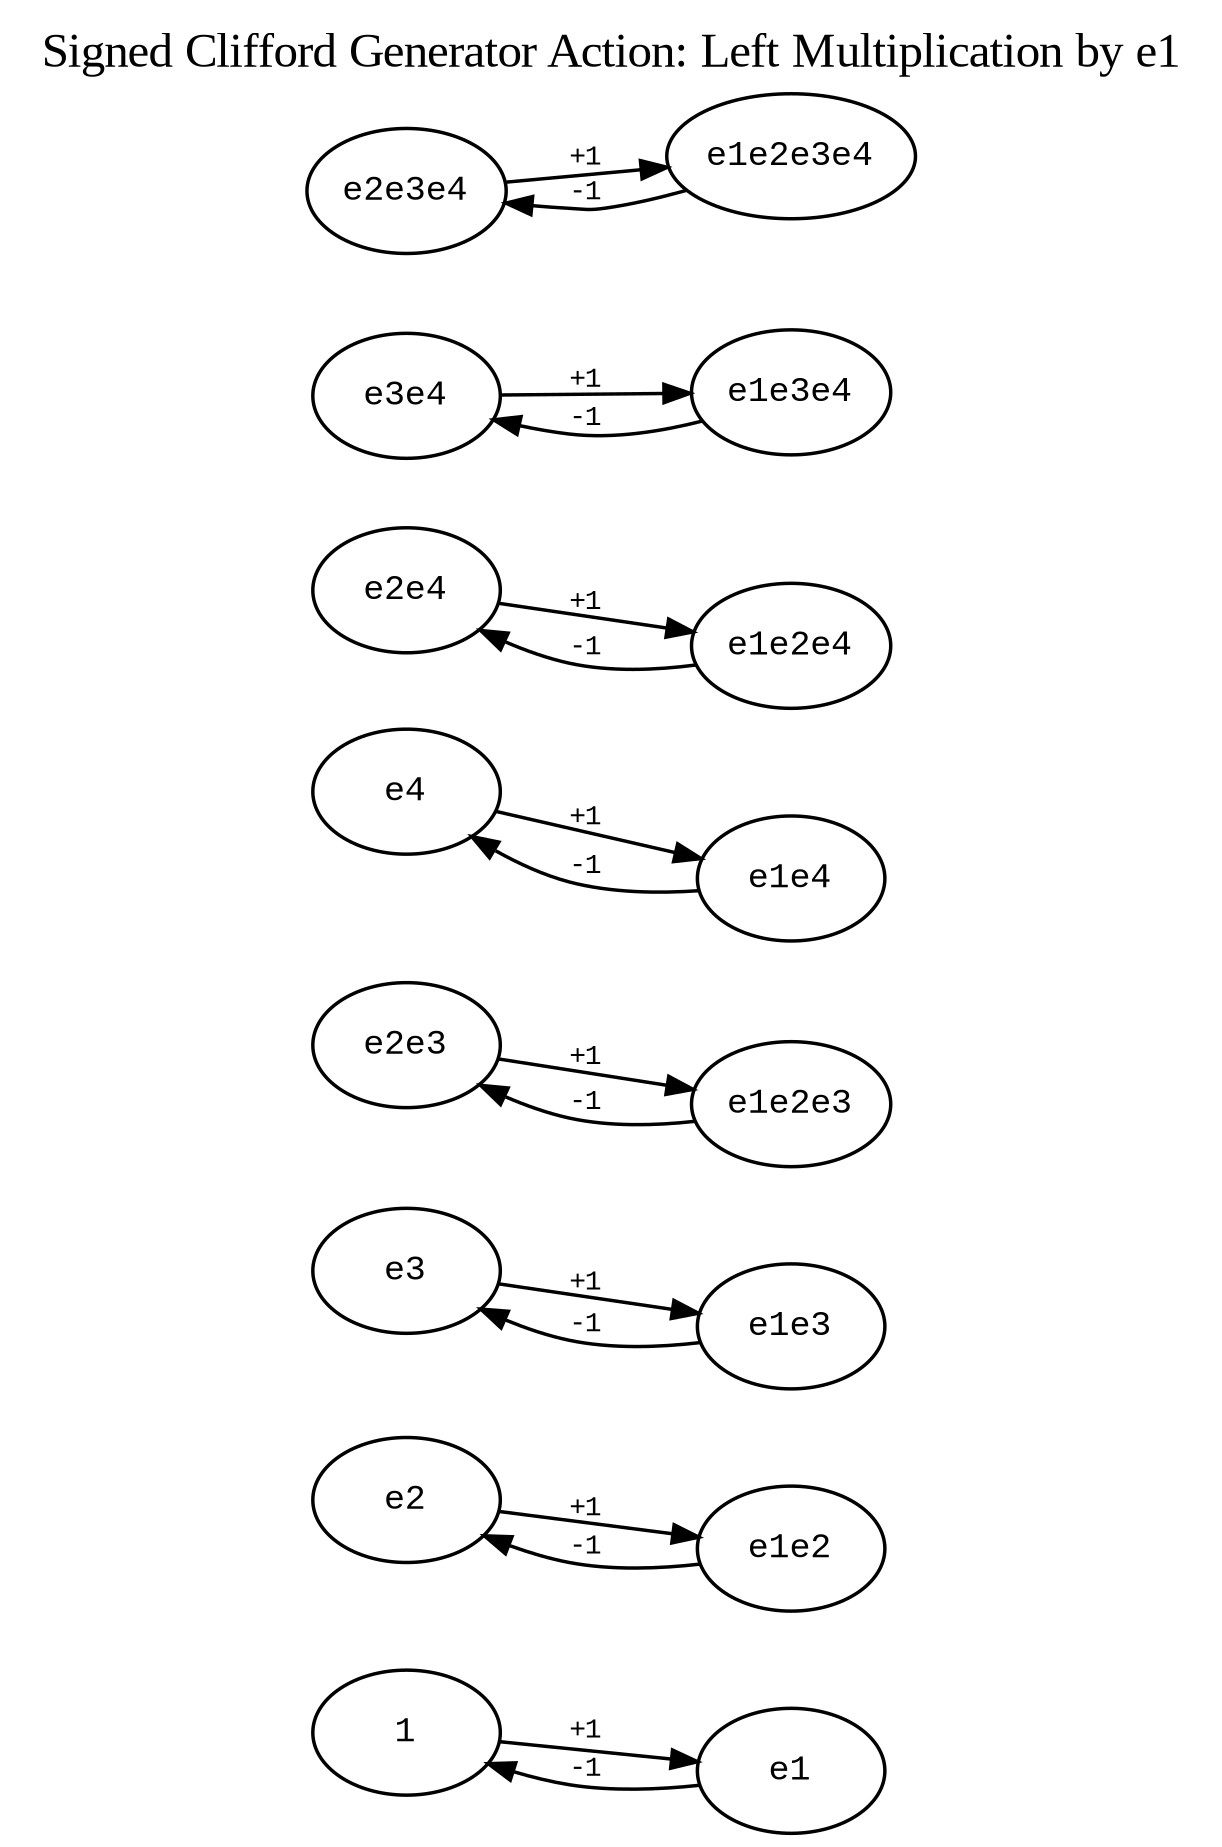

Saved 250 DPI graph PNG: /content/clifford_generator_action_graph.png


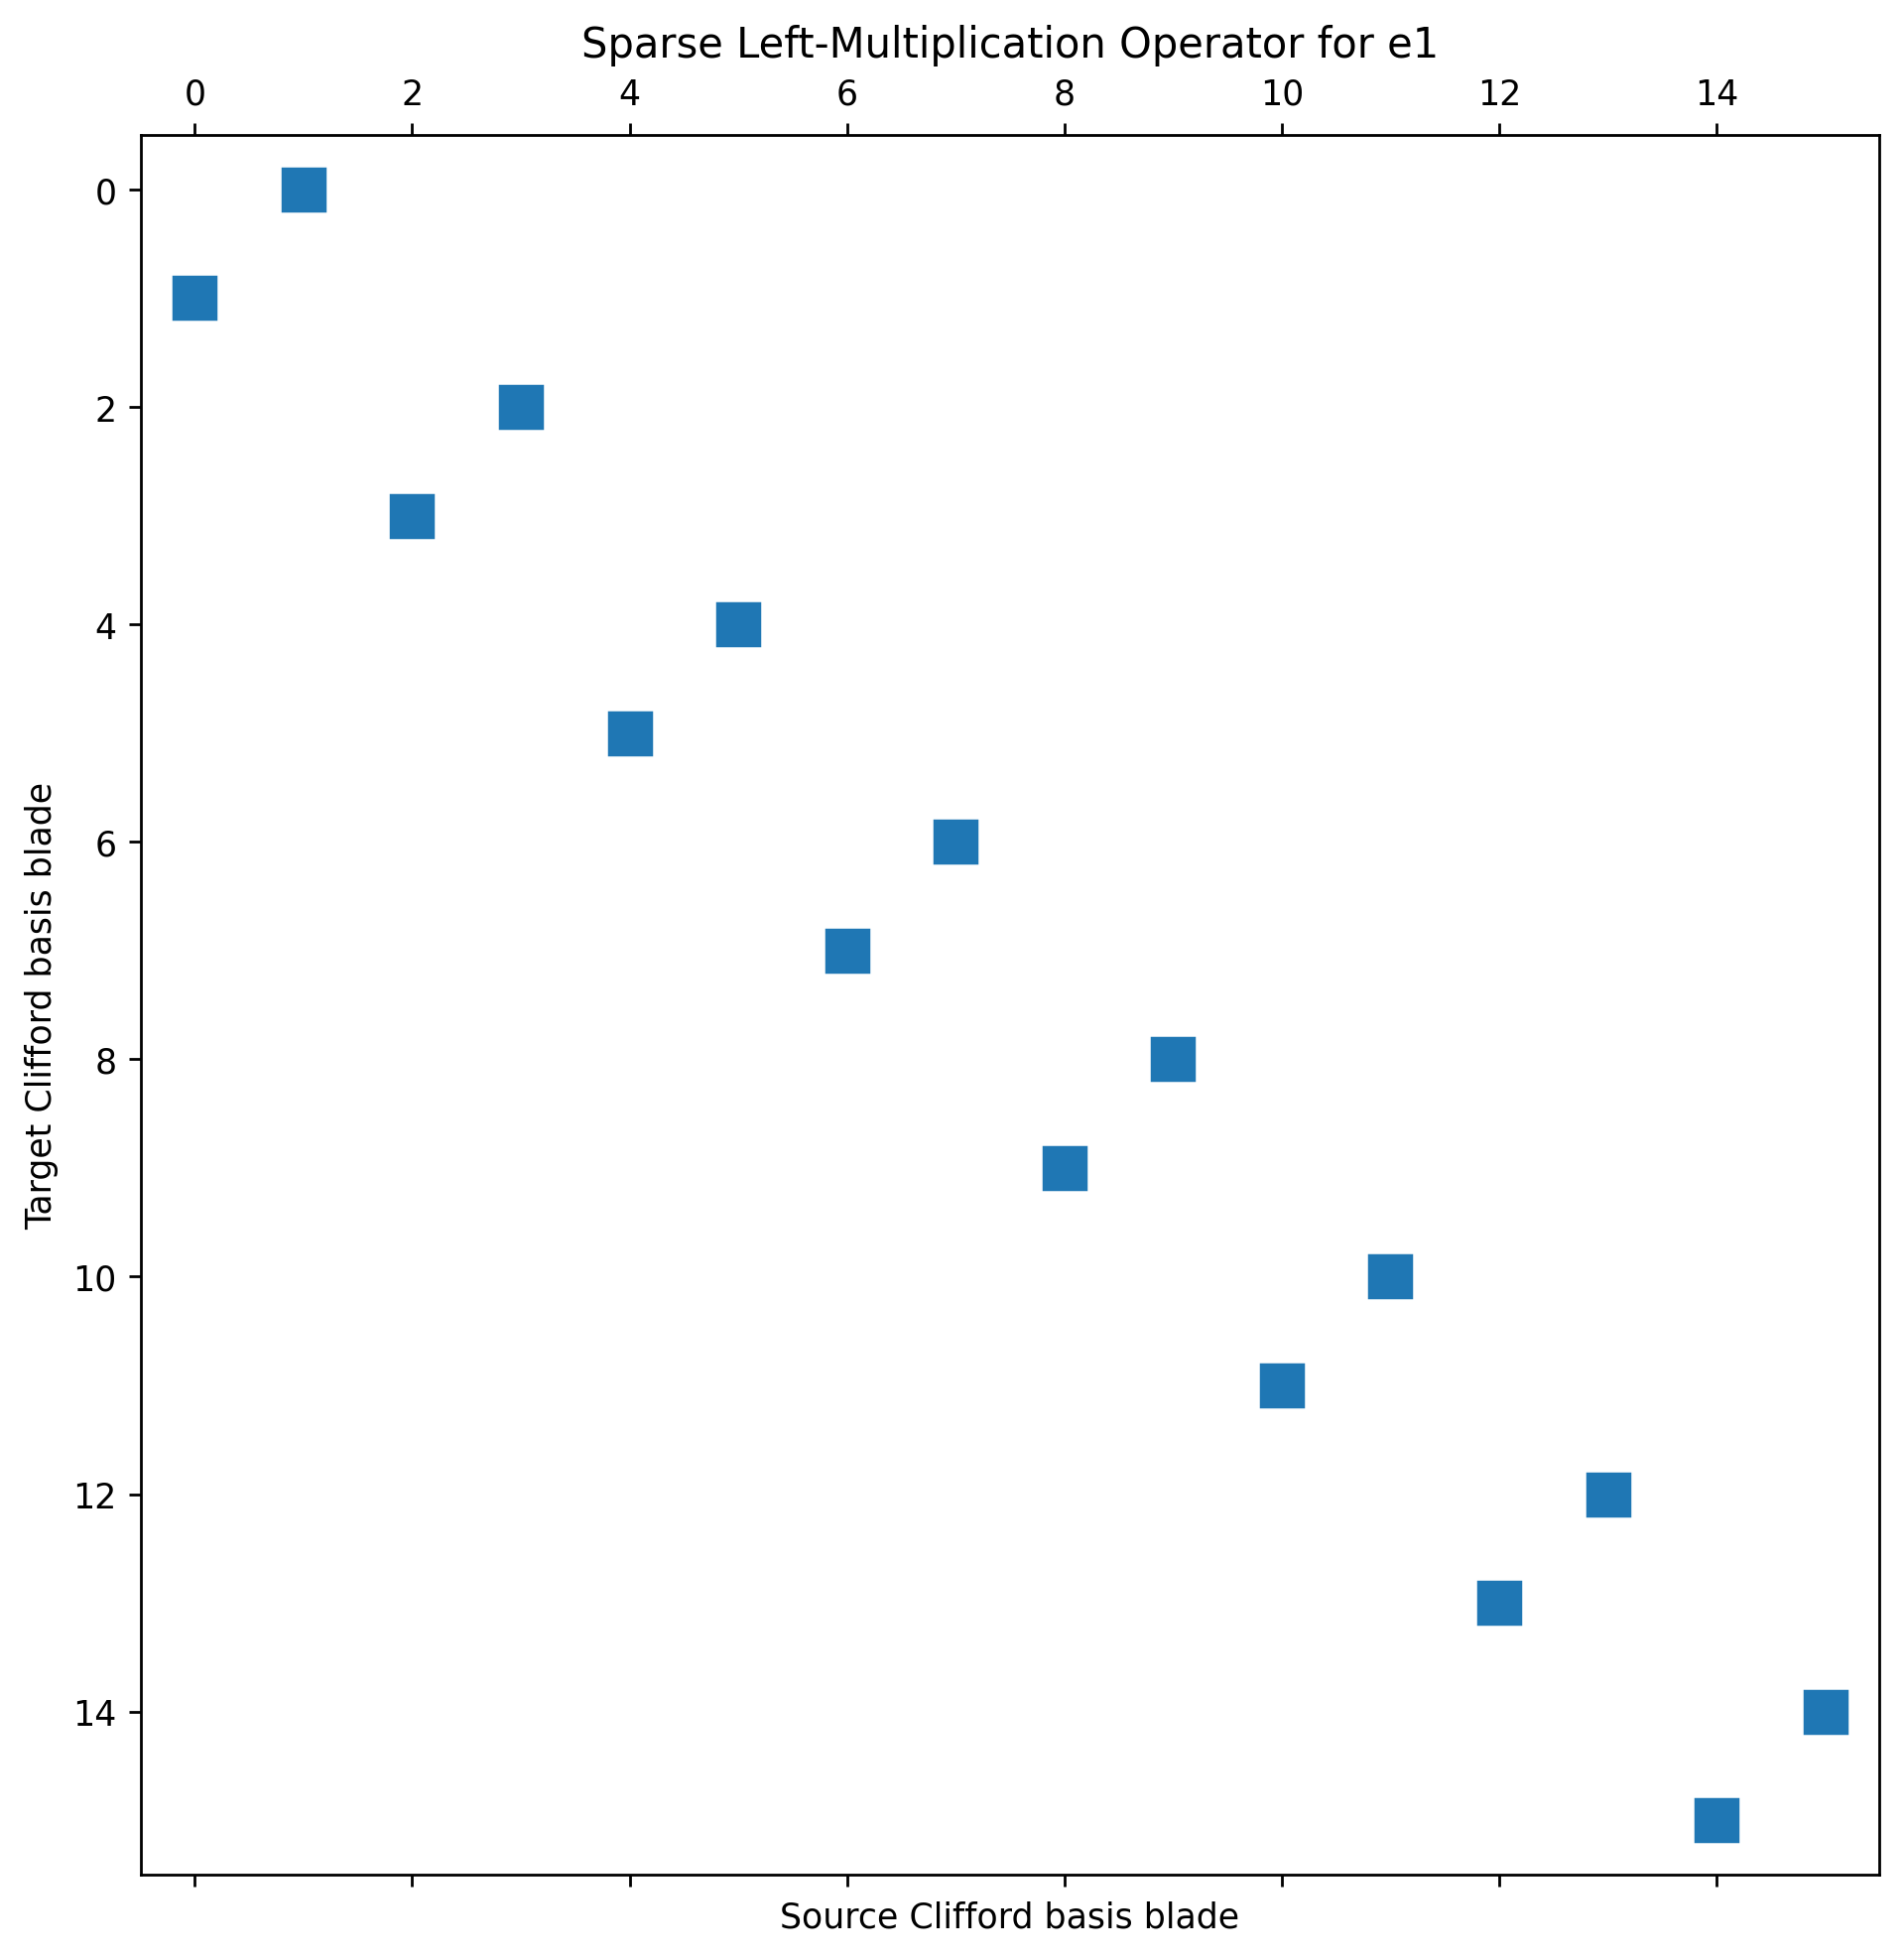

Saved 250 DPI sparse-plot PNG: /content/clifford_sparse_operator_pattern.png


In [34]:
"""Render a Clifford generator action graph and sparse operator plot at 250 DPI."""

from io import BytesIO
from pathlib import Path

from google.colab import files
from IPython.display import Image, display

# ============================================================
# Control knobs
# ============================================================
CLIFFORD_GRAPH_DPI = 250
CLIFFORD_GRAPH_FILENAME = "clifford_generator_action_graph.png"

SPY_PLOT_DPI = 250
SPY_FIGSIZE = (8, 8)
SPY_MARKERSIZE = 12
SPY_PLOT_FILENAME = "clifford_sparse_operator_pattern.png"

plt.rcParams["figure.dpi"] = SPY_PLOT_DPI
plt.rcParams["savefig.dpi"] = SPY_PLOT_DPI

# ============================================================
# Build the Clifford action graph
# ============================================================
clifford_operator = clifford_operators[1]
clifford_graph = nx.from_scipy_sparse_array(
    clifford_operator.T,
    create_using=nx.DiGraph,
    edge_attribute="weight",
)

basis_labels = clifford_adjacency["basis_labels"]
clifford_node_labels = {}
for node, basis_word in enumerate(basis_labels):
    if basis_word:
        clifford_node_labels[node] = "".join(
            f"e{index}"
            for index in basis_word
        )
    else:
        clifford_node_labels[node] = "1"

clifford_edge_labels = {
    (source, target): f"{data['weight']:+g}"
    for source, target, data in clifford_graph.edges(data=True)
}

# ============================================================
# Render the Graphviz graph
# ============================================================
clifford_dot, clifford_graph_view = render_networkx_graph(
    clifford_graph,
    title="Signed Clifford Generator Action: Left Multiplication by e1",
    node_labels=clifford_node_labels,
    edge_labels=clifford_edge_labels,
    rankdir="LR",
)

clifford_dot.attr(dpi=str(CLIFFORD_GRAPH_DPI))

clifford_graph_png = clifford_dot.pipe(format="png")
clifford_graph_buffer = BytesIO(clifford_graph_png)

display(Image(data=clifford_graph_buffer.getvalue()))

clifford_graph_path = Path(CLIFFORD_GRAPH_FILENAME)
clifford_graph_path.write_bytes(clifford_graph_buffer.getvalue())

CLIFFORD_DOT_SOURCE = clifford_dot.source

print(f"Saved 250 DPI graph PNG: {clifford_graph_path.resolve()}")

# ============================================================
# Render the sparse operator pattern plot
# ============================================================
fig, ax = plt.subplots(figsize=SPY_FIGSIZE)
ax.spy(clifford_operator, markersize=SPY_MARKERSIZE)
ax.set_title("Sparse Left-Multiplication Operator for e1")
ax.set_xlabel("Source Clifford basis blade")
ax.set_ylabel("Target Clifford basis blade")
fig.tight_layout()

spy_plot_buffer = BytesIO()
fig.savefig(
    spy_plot_buffer,
    format="png",
    dpi=SPY_PLOT_DPI,
    bbox_inches="tight",
)
plt.close(fig)

display(Image(data=spy_plot_buffer.getvalue()))

spy_plot_path = Path(SPY_PLOT_FILENAME)
spy_plot_path.write_bytes(spy_plot_buffer.getvalue())

print(f"Saved 250 DPI sparse-plot PNG: {spy_plot_path.resolve()}")

## Reusable Poincaré and graded-series bookkeeping

For an exact decomposition

$$
H(q)=A(q)X(q)+B(q)Y(q)+Z(q),
$$

the unknown component $X(q)$ can be recovered by exact polynomial division whenever the problem is well posed. A zero remainder certifies exact reconstruction in the polynomial ring.

In [35]:
"""Recover an unknown exact graded component and verify reconstruction."""


def recover_graded_component(h_poly, a_poly, b_poly, y_poly, z_poly, variable):
    """Recover X from H = A*X + B*Y + Z by exact polynomial division.

    Args:
        h_poly: Known total graded polynomial H.
        a_poly: Known multiplier A.
        b_poly: Known multiplier B.
        y_poly: Known graded component Y.
        z_poly: Known residual component Z.
        variable: Polynomial grading variable.

    Returns:
        Dictionary with quotient, remainder, and reconstruction status.
    """
    numerator = sp.Poly(
        sp.expand(h_poly - b_poly * y_poly - z_poly),
        variable,
        domain=sp.QQ,
    )
    denominator = sp.Poly(a_poly, variable, domain=sp.QQ)
    quotient, remainder = sp.div(numerator, denominator)
    recovered = quotient.as_expr()
    reconstructed = sp.expand(
        a_poly * recovered + b_poly * y_poly + z_poly
    )
    exact = remainder.is_zero and sp.expand(reconstructed - h_poly) == 0
    return {
        "quotient": recovered,
        "remainder": remainder.as_expr(),
        "reconstructed": reconstructed,
        "exact": bool(exact),
    }


q = sp.symbols("q")
A_Q = 1 + q + q**2
B_Q = 1 + q**2
X_TRUE = 1 + q**3 + q**5
Y_Q = q + q**4
Z_Q = q**7
H_Q = sp.expand(A_Q * X_TRUE + B_Q * Y_Q + Z_Q)

series_result = recover_graded_component(H_Q, A_Q, B_Q, Y_Q, Z_Q, q)

display(Math(rf"H(q)={sp.latex(H_Q)}"))
display(Math(rf"X(q)={sp.latex(series_result['quotient'])}"))
display(Math(rf"R(q)={sp.latex(series_result['remainder'])}"))

assert series_result["exact"]
assert sp.expand(series_result["quotient"] - X_TRUE) == 0

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Independent Z3 counterexample rejection

For supported polynomial expressions, the verifier asks whether a real or integer assignment satisfying the assumptions can make the residual nonzero. `unsat` means Z3 has rejected all such counterexamples within the encoded theory.

In [36]:
"""Demonstrate SMT verification of a polynomial identity."""

Z3_LHS = (x + 1) ** 2
Z3_RHS = x**2 + 2 * x + 1
z3_check = verify_equivalence(Z3_LHS, Z3_RHS, (x,))

print(z3_check)
assert z3_check["proved"]
assert z3_check["status"] in ("exact_symbolic", "smt_verified")

# Force the explicit Z3 route with an independently constructed solver.
zx = z3.Real("zx")
solver = z3.Solver()
solver.add((zx + 1) * (zx + 1) != zx * zx + 2 * zx + 1)
assert solver.check() == z3.unsat
print("Explicit Z3 counterexample search: unsat")

{'status': 'exact_symbolic', 'proved': True, 'mpmath_ok': True, 'cupy_ok': True, 'max_error': 0.0}
Explicit Z3 counterexample search: unsat


## CuPy batched numerical consistency check

This section performs a large CUDA batch independently of SymPy's exact result. It is useful for stress testing transformations over many admissible points. It remains a numerical consistency test, regardless of sample count.

In [37]:
"""Run an explicit CuPy batched numerical identity check on the GPU."""

if GPU_AVAILABLE:
    rng = cp.random.RandomState(RANDOM_SEED)
    x_gpu = rng.uniform(0.125, 3.0, size=GPU_SAMPLES)
    lhs_gpu = (x_gpu + 1.0) ** 4
    rhs_gpu = (
        x_gpu**4
        + 4.0 * x_gpu**3
        + 6.0 * x_gpu**2
        + 4.0 * x_gpu
        + 1.0
    )
    gpu_max_error = float(cp.max(cp.abs(lhs_gpu - rhs_gpu)).get())
    print(f"CuPy samples: {GPU_SAMPLES:,}")
    print(f"Maximum absolute residual: {gpu_max_error:.3e}")
    assert gpu_max_error <= 1e-9
else:
    print(
        "No CUDA device is active. In Google Colab, select a GPU runtime "
        "to execute the CuPy verification section."
    )

CuPy samples: 32,768
Maximum absolute residual: 5.684e-14


## Chain-complex incidence as adjacency

Boundary maps already have the structure of sparse weighted adjacency operators. For a chain complex

$$
C_2\xrightarrow{\partial_2}C_1\xrightarrow{\partial_1}C_0,
$$

the chain condition is

$$
\partial_1\partial_2=0.
$$

The example below uses an oriented filled triangle. Its boundary matrices are represented exactly with SymPy and sparsely with SciPy. Kernels and images then give the Betti numbers

$$
b_k=\dim\ker\partial_k-\operatorname{rank}\partial_{k+1}.
$$

This representation provides a direct path from adjacency-oriented computation to future modules, exact sequences, homology, and GPU sparse linear algebra.


In [38]:
"""Represent a small chain complex with sparse incidence operators."""

# ============================================================
# Control knobs
# ============================================================
GPU_SPARSE_DTYPE = np.float64
GPU_ZERO_TOLERANCE = 1.0e-12

# ============================================================
# Exact symbolic chain complex
# ============================================================
boundary_1 = sp.Matrix(
    [
        [-1, 0, -1],
        [1, -1, 0],
        [0, 1, 1],
    ]
)

boundary_2 = sp.Matrix(
    [
        [1],
        [1],
        [-1],
    ]
)

# Verify the exact chain condition d_1 d_2 = 0.
chain_residual = boundary_1 * boundary_2

assert chain_residual == sp.zeros(
    boundary_1.rows,
    boundary_2.cols,
)

# ============================================================
# Betti numbers
# ============================================================
rank_d1 = boundary_1.rank()
rank_d2 = boundary_2.rank()

num_vertices = boundary_1.rows
num_edges = boundary_1.cols
num_faces = boundary_2.cols

betti_0 = num_vertices - rank_d1
betti_1 = num_edges - rank_d1 - rank_d2
betti_2 = num_faces - rank_d2

BETTI_NUMBERS = (
    int(betti_0),
    int(betti_1),
    int(betti_2),
)

assert BETTI_NUMBERS == (1, 0, 0)

# ============================================================
# CPU sparse representation
# ============================================================
boundary_1_sparse = sps.csr_matrix(
    np.asarray(
        boundary_1.tolist(),
        dtype=np.int64,
    )
)

boundary_2_sparse = sps.csr_matrix(
    np.asarray(
        boundary_2.tolist(),
        dtype=np.int64,
    )
)

sparse_chain_residual = boundary_1_sparse @ boundary_2_sparse

# Sparse multiplication can retain explicitly stored zeros.
sparse_chain_residual.eliminate_zeros()

assert sparse_chain_residual.nnz == 0

print("Betti numbers (b0, b1, b2):", BETTI_NUMBERS)
print("d1 sparse nonzeros:", boundary_1_sparse.nnz)
print("d2 sparse nonzeros:", boundary_2_sparse.nnz)

# ============================================================
# CUDA sparse representation
# ============================================================
if GPU_AVAILABLE and cp_sparse is not None:
    # Preserve exact integer incidence matrices on the CPU.
    # CUDA sparse algebra uses a supported floating-point dtype.
    boundary_1_gpu_ready = boundary_1_sparse.astype(
        GPU_SPARSE_DTYPE,
        copy=False,
    )

    boundary_2_gpu_ready = boundary_2_sparse.astype(
        GPU_SPARSE_DTYPE,
        copy=False,
    )

    gpu_d1 = cp_sparse.csr_matrix(boundary_1_gpu_ready)
    gpu_d2 = cp_sparse.csr_matrix(boundary_2_gpu_ready)

    gpu_chain_residual = gpu_d1 @ gpu_d2

    # CuPy CSR multiplication may store explicit zero entries.
    # Remove them before interpreting nnz as mathematical support.
    gpu_chain_residual.eliminate_zeros()

    assert gpu_chain_residual.nnz == 0

    # Numerical verification is useful for larger floating-point
    # chain complexes where roundoff can generate tiny residuals.
    if gpu_chain_residual.data.size:
        max_chain_error = float(
            cp.max(cp.abs(gpu_chain_residual.data)).get()
        )
    else:
        max_chain_error = 0.0

    assert max_chain_error <= GPU_ZERO_TOLERANCE

    print("CUDA sparse chain condition check passed.")
    print("CUDA d1 dtype:", gpu_d1.dtype)
    print("CUDA d2 dtype:", gpu_d2.dtype)
    print("CUDA residual nnz:", gpu_chain_residual.nnz)
    print("CUDA max |d1 @ d2|:", max_chain_error)

Betti numbers (b0, b1, b2): (1, 0, 0)
d1 sparse nonzeros: 6
d2 sparse nonzeros: 3
CUDA sparse chain condition check passed.
CUDA d1 dtype: float64
CUDA d2 dtype: float64
CUDA residual nnz: 0
CUDA max |d1 @ d2|: 0.0


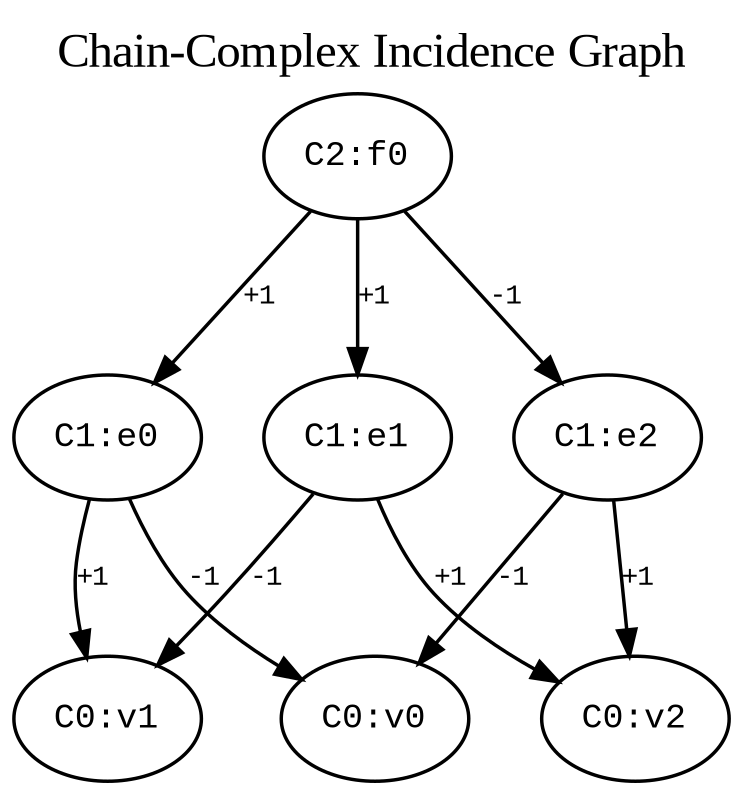


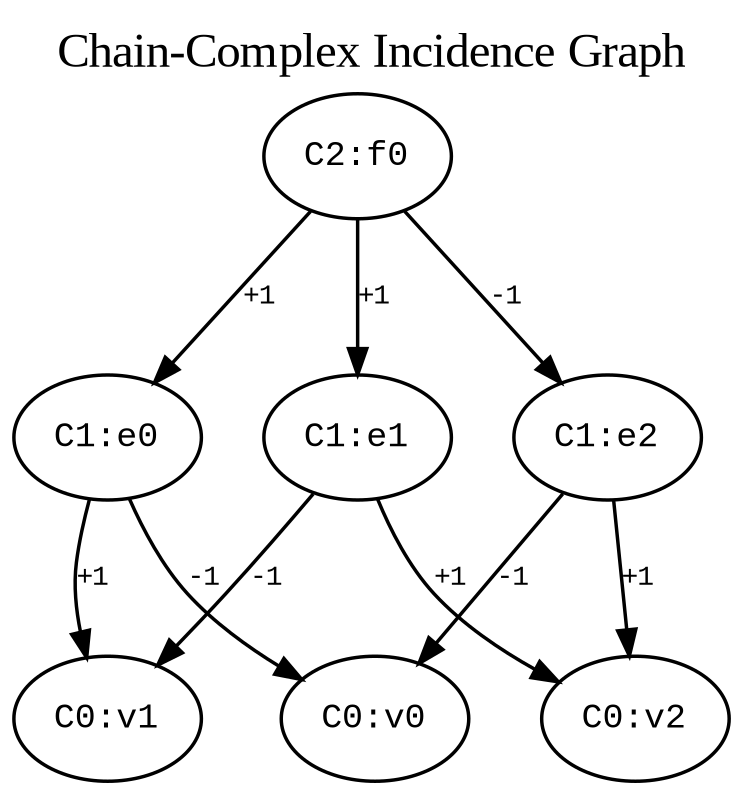

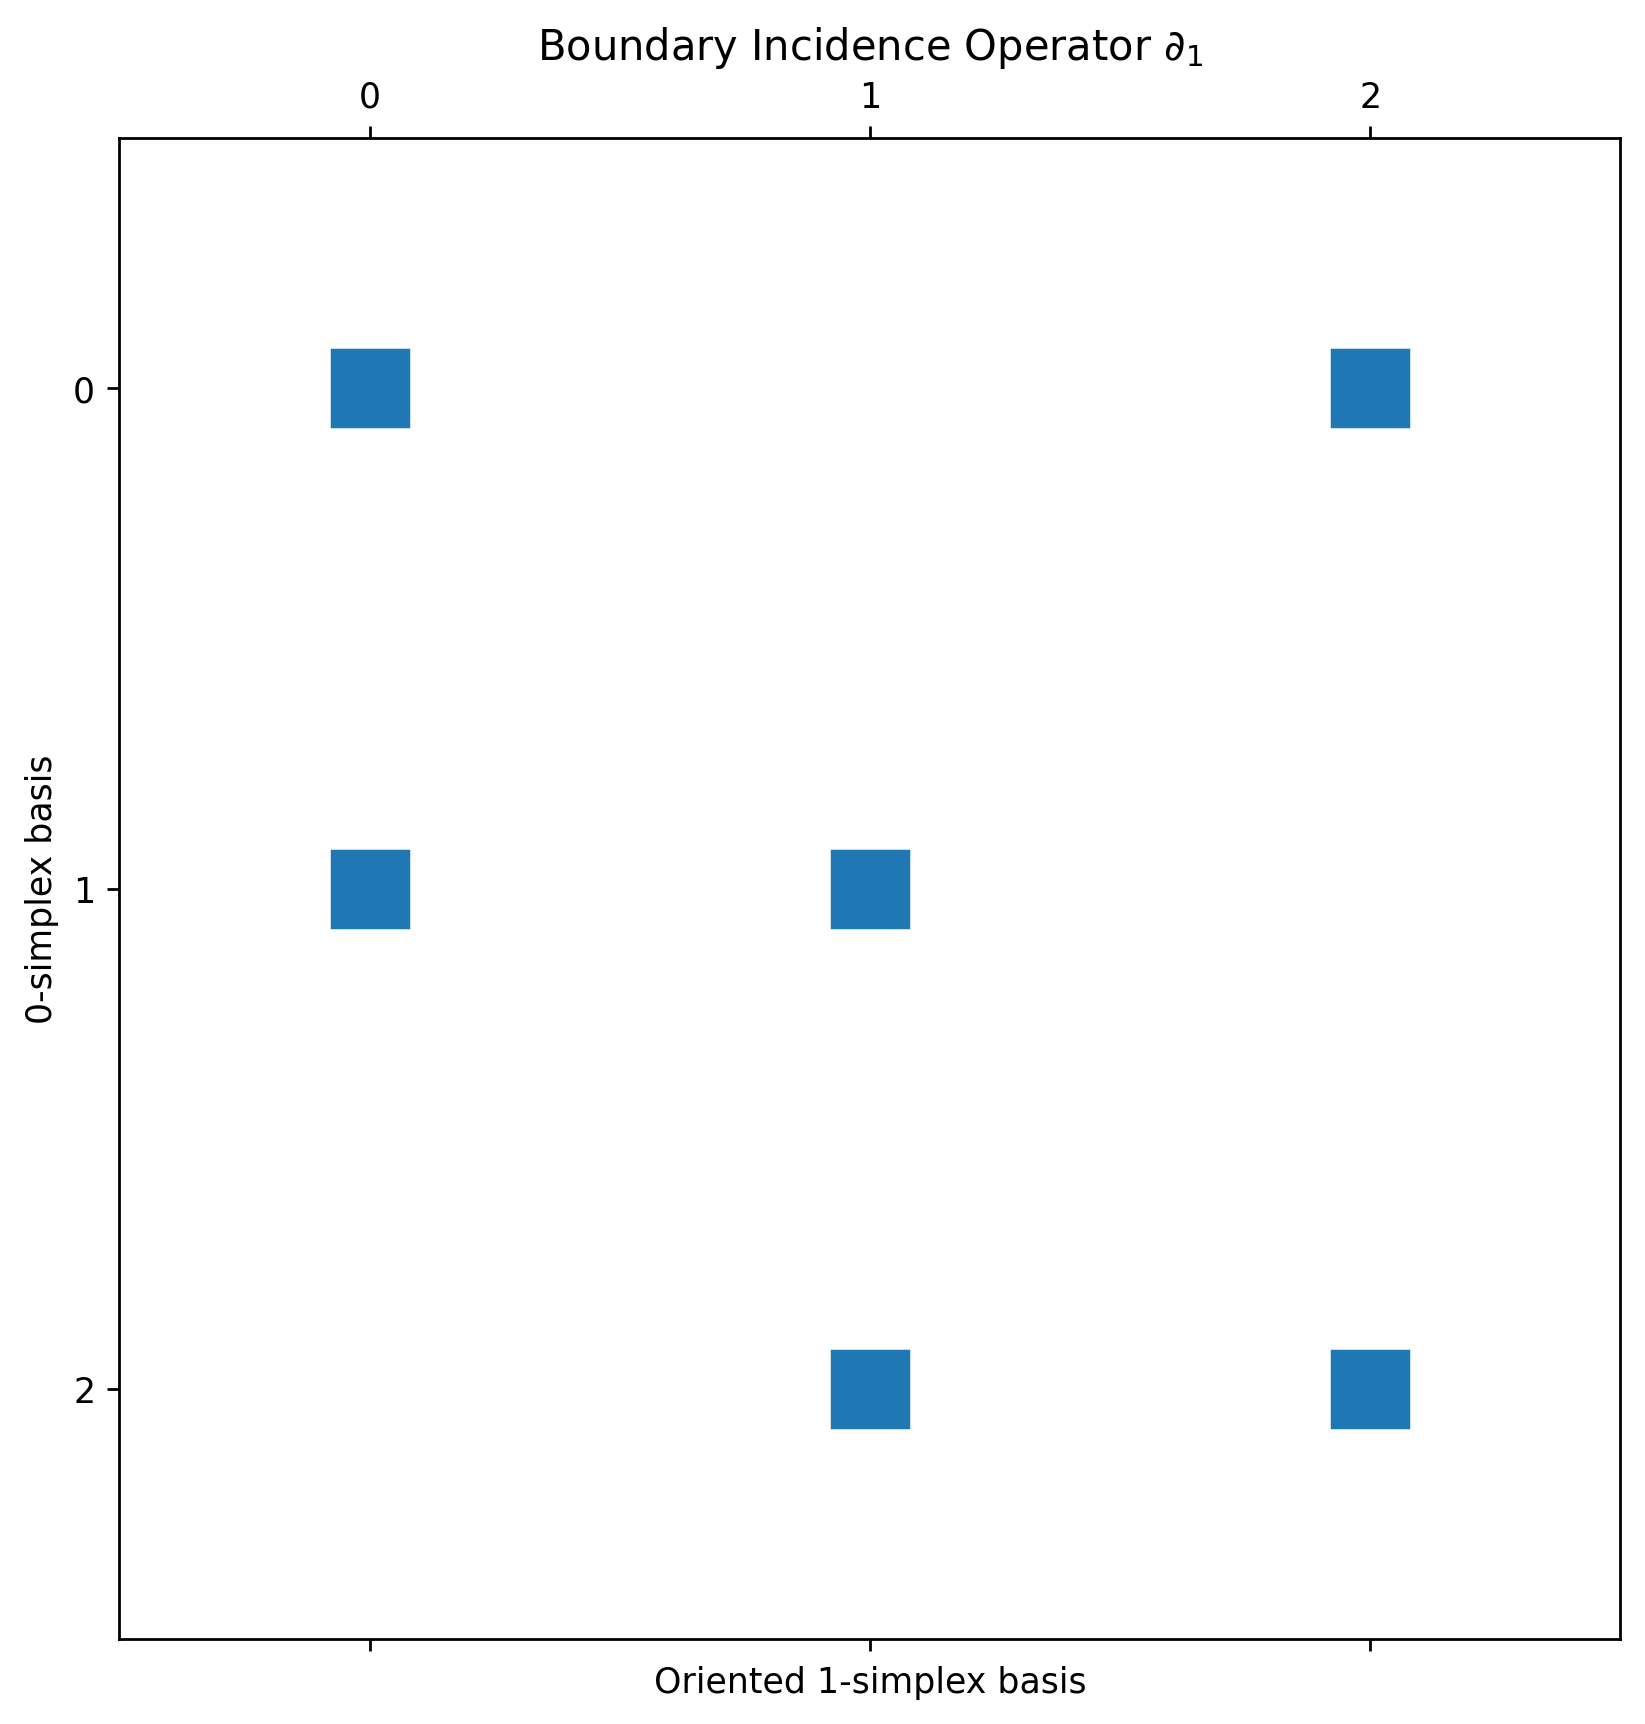

In [39]:
"""Render the chain-complex incidence graph and sparse boundary operator."""

import base64
from io import BytesIO

import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import HTML, Image, display

# ============================================================
# Control knobs
# ============================================================
GRAPHVIZ_FORMAT = "png"
GRAPHVIZ_DPI = 250
GRAPH_PNG_FILENAME = "chain_complex_incidence_graph.png"
GRAPH_TITLE = "Chain-Complex Incidence Graph"

PLOT_DPI = 250
SPY_FIGSIZE = (7, 7)
SPY_MARKERSIZE = 22

plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["savefig.dpi"] = PLOT_DPI

# ============================================================
# Build the chain-complex incidence graph
# ============================================================
chain_graph = nx.DiGraph()

vertex_nodes = [f"v{index}" for index in range(boundary_1.rows)]
edge_nodes = [f"e{index}" for index in range(boundary_1.cols)]
face_nodes = [f"f{index}" for index in range(boundary_2.cols)]

for node in vertex_nodes:
    chain_graph.add_node(node, degree=0)

for node in edge_nodes:
    chain_graph.add_node(node, degree=1)

for node in face_nodes:
    chain_graph.add_node(node, degree=2)

for row in range(boundary_1.rows):
    for column in range(boundary_1.cols):
        coefficient = int(boundary_1[row, column])

        if coefficient != 0:
            chain_graph.add_edge(
                edge_nodes[column],
                vertex_nodes[row],
                coefficient=coefficient,
            )

for row in range(boundary_2.rows):
    for column in range(boundary_2.cols):
        coefficient = int(boundary_2[row, column])

        if coefficient != 0:
            chain_graph.add_edge(
                face_nodes[column],
                edge_nodes[row],
                coefficient=coefficient,
            )

chain_node_labels = {
    node: f"C{data['degree']}:{node}"
    for node, data in chain_graph.nodes(data=True)
}

chain_edge_labels = {
    (source, target): f"{data['coefficient']:+d}"
    for source, target, data in chain_graph.edges(data=True)
}

# ============================================================
# Render the Graphviz incidence graph
# ============================================================
chain_dot, chain_graph_view = render_networkx_graph(
    chain_graph,
    title=GRAPH_TITLE,
    node_labels=chain_node_labels,
    edge_labels=chain_edge_labels,
    rankdir="TB",
)

# Set Graphviz bitmap rendering resolution.
chain_dot.graph_attr["dpi"] = str(GRAPHVIZ_DPI)

# Equivalent syntax:
# chain_dot.attr("graph", dpi=str(GRAPHVIZ_DPI))

# Render the PNG entirely in memory.
chain_png_bytes = chain_dot.pipe(format=GRAPHVIZ_FORMAT)

# ============================================================
# Display the in-memory Graphviz PNG
# ============================================================
display(Image(data=chain_png_bytes))

# ============================================================
# Create an in-memory Graphviz PNG download link
# ============================================================
chain_png_b64 = base64.b64encode(chain_png_bytes).decode("ascii")

download_html = f"""
<a
    download="{GRAPH_PNG_FILENAME}"
    href="data:image/png;base64,{chain_png_b64}"
>
    Download {GRAPH_PNG_FILENAME} ({GRAPHVIZ_DPI} DPI)
</a>
"""

display(HTML(download_html))

# Retain a file-like in-memory buffer for downstream processing.
chain_png_buffer = BytesIO(chain_png_bytes)
chain_png_buffer.seek(0)

# ============================================================
# Sparse boundary operator
# ============================================================
fig, ax = plt.subplots(
    figsize=SPY_FIGSIZE,
    dpi=PLOT_DPI,
)

ax.spy(
    boundary_1_sparse,
    markersize=SPY_MARKERSIZE,
)

ax.set_title("Boundary Incidence Operator $\\partial_1$")
ax.set_xlabel("Oriented 1-simplex basis")
ax.set_ylabel("0-simplex basis")

fig.tight_layout()
plt.show()

## LaTeX export

The selected polynomial path is exported as an `align` environment suitable for Overleaf. Transformation labels remain attached to individual steps.

In [40]:
"""Export the selected derivation as an Overleaf-ready LaTeX align block."""

latex_lines = [r"\begin{align}"]
for index, step in enumerate(poly_result["selected_path"]):
    expression_latex = sp.latex(step["expr"])
    if index == 0:
        latex_lines.append(rf"E_0 &= {expression_latex} \\")
    else:
        latex_lines.append(
            rf"E_{index} &= {expression_latex} "
            rf"\qquad \text{{[{step['rule']}]}} \\"
        )
latex_lines.append(r"\end{align}")

latex_derivation = "\n".join(latex_lines)
print(latex_derivation)

\begin{align}
E_0 &= x^{4} + 4 x^{3} + 6 x^{2} + 4 x + 1 \\
E_1 &= \left(x + 1\right)^{4} \qquad \text{[factor]} \\
\end{align}


## Extension data model

Graph structure and graph algorithms remain in NetworkX. Network visualization is delegated to Graphviz, while Matplotlib is reserved for matrix-oriented diagnostics such as sparse operator patterns.

```text
Automated Mathematical Derivation Engine
│
├── Symbolic algebra
│   ├── exact rewrites
│   ├── objective-driven search
│   └── assumptions
│
├── Verification
│   ├── SymPy exact checks
│   ├── Z3 SMT checks
│   ├── mpmath high-precision checks
│   └── CuPy batched GPU checks
│
├── Adjacency layer
│   ├── expression adjacency
│   ├── rule-specific adjacency
│   ├── sparse weighted operators
│   ├── rule-transition scoring
│   └── CUDA sparse frontier propagation
│
├── Graph layer
│   ├── NetworkX graph construction
│   ├── NetworkX traversal and analytics
│   ├── competing derivation branches
│   ├── ranked paths
│   └── subgraph selection
│
├── Visualization layer
│   ├── Graphviz derivation DAG
│   ├── Graphviz rule-transition graph
│   ├── Graphviz Clifford action graph
│   ├── Graphviz chain-incidence graph
│   └── Matplotlib sparse-matrix diagnostics
│
├── Clifford algebra
│   ├── canonical words
│   ├── signed generator adjacency
│   ├── metric factors
│   ├── Z/2Z grading
│   └── Koszul signs
│
├── Graded algebra
│   ├── graded tensor products
│   ├── modules
│   └── chain complexes
│
├── Chain and exact-sequence layer
│   ├── sparse boundary maps
│   ├── kernels
│   ├── images
│   ├── quotient objects
│   └── exactness checks
│
└── Optional SageMath backend
    ├── groups
    ├── rings and modules
    ├── Clifford algebras
    ├── Steenrod algebra
    ├── chain complexes
    ├── homology and cohomology
    └── selected bordism computations
```

The schema below records these interfaces without importing SageMath into the Colab runtime.


In [41]:
"""Declare extension interfaces for algebraic-topology backends."""

EXTENSION_SCHEMA = {
    "adjacency": {
        "expression_operator": "scipy.sparse.csr_matrix",
        "rule_operators": {},
        "gpu_operator": "cupyx.scipy.sparse.csr_matrix",
        "transition_costs": RULE_TRANSITION_COSTS,
    },
    "visualization": {
        "graph_structure": "networkx.DiGraph",
        "network_renderer": "graphviz.Digraph",
        "layout_engine": GRAPHVIZ_ENGINE,
        "render_format": GRAPHVIZ_FORMAT,
        "matrix_renderer": "matplotlib",
    },
    "graded_module": {
        "ring": None,
        "generators": [],
        "degrees": {},
        "relations": [],
    },
    "chain_complex": {
        "chain_groups": {},
        "boundary_maps": {},
        "coefficient_ring": None,
        "sparse_backend": "csr",
    },
    "exact_sequence": {
        "objects": [],
        "maps": [],
        "kernels": {},
        "images": {},
        "exactness": {},
    },
    "sage_backend": {
        "enabled": False,
        "capabilities": (
            "groups",
            "rings",
            "modules",
            "steenrod_algebra",
            "homology",
            "cohomology",
            "bordism_bookkeeping",
        ),
    },
}

print(EXTENSION_SCHEMA["adjacency"])
print(EXTENSION_SCHEMA["visualization"])
print(EXTENSION_SCHEMA["sage_backend"])

{'expression_operator': 'scipy.sparse.csr_matrix', 'rule_operators': {}, 'gpu_operator': 'cupyx.scipy.sparse.csr_matrix', 'transition_costs': {('expand', 'collect'): 0.35, ('expand_trig', 'trigsimp'): 0.2, ('together', 'cancel'): 0.25, ('together', 'ratsimp'): 0.35, ('ratsimp', 'factor'): 0.5, ('factor', 'simplify'): 0.6, ('factor', 'expand'): 1.75, ('cancel', 'together'): 1.4}}
{'graph_structure': 'networkx.DiGraph', 'network_renderer': 'graphviz.Digraph', 'layout_engine': 'dot', 'render_format': 'png', 'matrix_renderer': 'matplotlib'}
{'enabled': False, 'capabilities': ('groups', 'rings', 'modules', 'steenrod_algebra', 'homology', 'cohomology', 'bordism_bookkeeping')}


## Lightweight integrity checks

The principal demonstrations already contain local assertions. The checks below confirm graph acyclicity, verified edge metadata, sparse adjacency consistency, exact graded reconstruction, Clifford operator relations, and the chain condition.


In [43]:
"""Run compact integrity checks across the notebook."""

PNG_SIGNATURE = b"\x89PNG\r\n\x1a\n"


def is_valid_graphviz_png(dot_graph):
    """Check whether a Graphviz graph renders to a valid PNG byte stream.

    Args:
        dot_graph: Graphviz Digraph to render and inspect.

    Returns:
        True if the rendered byte stream begins with the PNG signature.
    """
    png_data = dot_graph.pipe(format="png")
    return png_data.startswith(PNG_SIGNATURE)


# ============================================================
# Derivation graph integrity
# ============================================================
assert nx.is_directed_acyclic_graph(poly_result["graph"])

assert isinstance(derivation_dot, Digraph)
assert isinstance(rule_transition_dot, Digraph)
assert isinstance(clifford_dot, Digraph)
assert isinstance(chain_dot, Digraph)

# ============================================================
# Graphviz PNG rendering integrity
# ============================================================
assert is_valid_graphviz_png(derivation_dot)
assert is_valid_graphviz_png(rule_transition_dot)
assert is_valid_graphviz_png(clifford_dot)
assert is_valid_graphviz_png(chain_dot)

# ============================================================
# NetworkX graph integrity
# ============================================================
assert nx.is_directed(rule_transition_graph)
assert nx.is_directed(clifford_graph)
assert nx.is_directed(chain_graph)

# ============================================================
# Mathematical verification integrity
# ============================================================
assert all(
    poly_result["graph"].edges[source, target]["verification"]
    in (
        "exact_symbolic",
        "smt_verified",
        "numerically_consistent",
    )
    for source, target in poly_result["graph"].edges
)

assert A_EXPR.shape[0] == poly_result["graph"].number_of_nodes()
assert A_EXPR.nnz == poly_result["graph"].number_of_edges()

assert series_result["exact"]

# ============================================================
# Algebraic integrity
# ============================================================
assert clifford_result["word"] == tuple(
    sorted(clifford_result["word"])
)
assert koszul_result["sign"] == -1

assert candidate_table.shape[0] >= 1

# ============================================================
# Chain-complex integrity
# ============================================================
assert BETTI_NUMBERS == (1, 0, 0)
assert (boundary_1 * boundary_2) == sp.zeros(3, 1)

# ============================================================
# Clifford operator integrity
# ============================================================
for basis_index, operator in clifford_operators.items():
    residual = (
        operator @ operator
        - NEGATIVE_METRIC[basis_index] * clifford_identity
    )

    assert (
        residual.nnz == 0
        or np.max(np.abs(residual.data)) < 1e-12
    )

print("All integrity checks passed.")

All integrity checks passed.
